# **LOS/NLOS Classifier Model**

## **Project Setup**

### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [1]:
# import libraries
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    from scipy import stats

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [2]:
dataset_path = "../dataset/"  # Dataset directory

csv_files = [
    f for f in os.listdir(dataset_path) if f.endswith(".csv")
]  # Retrieve all csv files in the dataset folder

print(csv_files)  # print out all the csv file name in the 'dataset' folder

# Load and print out dataset values
dfs = []
for file in csv_files:
    print(f"Reading file: {file}")  # Print the file name being read
    df_temp = pd.read_csv(os.path.join(dataset_path, file))  # Read the CSV file
    # print(df_temp)  # Print the entire data of the current CSV file
    dfs.append(df_temp)  # Append the DataFrame to the list

df = pd.concat(
    dfs, ignore_index=True
)  # combining all datasets (csv) files into one DataFrame
print(df)

['uwb_dataset_part2.csv', 'uwb_dataset_part3.csv', 'uwb_dataset_part1.csv', 'uwb_dataset_part4.csv', 'uwb_dataset_part5.csv', 'uwb_dataset_part7.csv', 'uwb_dataset_part6.csv']
Reading file: uwb_dataset_part2.csv
Reading file: uwb_dataset_part3.csv
Reading file: uwb_dataset_part1.csv
Reading file: uwb_dataset_part4.csv
Reading file: uwb_dataset_part5.csv
Reading file: uwb_dataset_part7.csv
Reading file: uwb_dataset_part6.csv
       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09 

Reading the shape and columns of the dataframe provides information on all the data.

In [3]:
# 'df' variable => combine all dataframe into one
print(
    "Number of rows and Column in dataset:", df.shape
)  # shape of the datasets (the total columns and rolls -> matrix[columns,rows])
print(
    "Number of rows in dataset:", df.columns
)  # total columns/attribute in the all datasets

print(
    "number of records in overall datasets:", len(df)
)  # Print the number of records in the all datasets

Number of rows and Column in dataset: (42000, 1031)
Number of rows in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)
number of records in overall datasets: 42000


## **1 - Data Preparation (Data Cleaning & Data Preprocessing)**

#### **1.1 - Data Cleaning**

1. Check and Handle Missing Values

In [4]:
# Calculate the missing values for each column
MissingValCount = df.isnull().sum()

# If there are missing values, drop them and create a new cleaned dataset
if MissingValCount.sum() > 0:
    df_clean = df.dropna()  # Drop rows with missing values
    print(
        f"Total missing values found and removed: {MissingValCount.sum()} rows dropped."
    )
else:
    df_clean = df.copy()  # If no missing values, just copy the original dataset
    print("No missing values found in datasets")

No missing values found in datasets


2. Display Dataset Shape Before and After Cleaning

In [5]:
# Display the shape of the dataset before and after cleaning
print("Before cleaning, dataset rows and columns:", df.shape)
print("After cleaning, dataset rows and columns:", df_clean.shape)

# Check if there is a difference in rows or columns
if df.shape == df_clean.shape:
    print("The number of rows and columns are the same in both datasets.")
else:
    rows_diff = df.shape[0] - df_clean.shape[0]
    cols_diff = df.shape[1] - df_clean.shape[1]
    print(
        "The number of rows and columns are different between the original and cleaned datasets.",
        f"Rows difference: {rows_diff}, Columns difference: {cols_diff}",
    )

Before cleaning, dataset rows and columns: (42000, 1031)
After cleaning, dataset rows and columns: (42000, 1031)
The number of rows and columns are the same in both datasets.


#### **1.2 -  Data Visualization and Target Variable Identification**


In [6]:
# import libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


##### **1.2.1 - Target Variable: NLOS**

**Count Occurrences of Values**

In [7]:
# count the total in NLOS attribute in the datasets
count_NLOS = df_clean["NLOS"].value_counts()

print(count_NLOS)

NLOS
1.0    21000
0.0    21000
Name: count, dtype: int64


**Data Vizualization**

The pie chart below illustrates the count for **NLOS** with labels 0.0 and 1.0. From the graph, we can observe that the distribution is perfectly balanced, with an equal count of 0.0 and 1.0 labels.

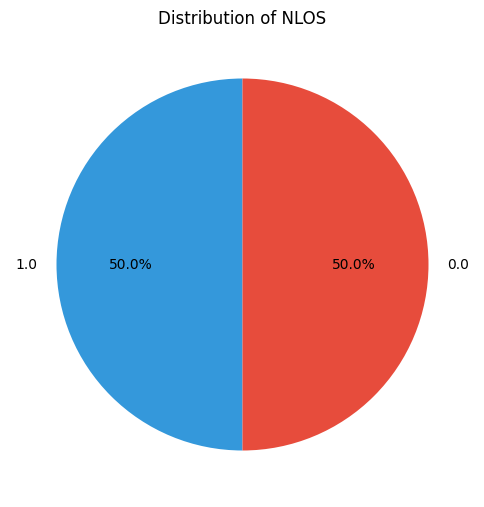

In [8]:
plt.figure(figsize=(6, 10))
count_NLOS.plot.pie(autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
plt.title("Distribution of NLOS")
plt.ylabel("")
plt.show()

##### **1.2.3 - Target Variable: FP_IDX**


**Identifying and Removing Outliers**

We be removing outliners Using IQR (Interquartile Range): 

1. Calculate IQR, Identify and Filter Outliers

In [9]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for FP_IDX
Q1 = df_clean["FP_IDX"].quantile(0.25)
Q3 = df_clean["FP_IDX"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in FP_IDX based on the bounds
outliers = df_clean[
    (df_clean["FP_IDX"] < lower_bound) | (df_clean["FP_IDX"] > upper_bound)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers)

# Filter out outliers separately for LOS and NLOS
# For LOS (Line of Sight)
df_clean_filtered_LOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 0.0)  # LOS condition
]

# For NLOS (Non-Line of Sight)
df_clean_filtered_NLOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 1.0)  # NLOS condition
]

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
26      1.0   4.54   737.0   2066.0   4232.0   3116.0         84.0   3789.0   
31      1.0   8.88   736.0   1823.0   1750.0   1277.0         76.0   4493.0   
46      1.0   5.86   737.0   3448.0   5723.0   3512.0         84.0    953.0   
49      1.0   7.32   734.0   2304.0   1919.0   1957.0         72.0   9314.0   
62      1.0  12.57   731.0   3438.0   1617.0   1713.0         76.0   1596.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41868   1.0   3.39   722.0    711.0   1391.0    829.0         88.0   2237.0   
41869   1.0   7.09   736.0   1501.0   1581.0    969.0         64.0    297.0   
41910   1.0   7.33   736.0    272.0   1719.0   1823.0         88.0   1561.0   
41969   1.0  13.13   727.0    719.0   1209.0   1395.0         88.0    924.0   
41982   1.0   4.64   733.0   1005.0   2047.0   1514.0         60.0    396.0   

       MAX_NOISE  RXPACC  .

2. Combine Data, Clean Redundant Columns, and Rename

In [10]:
# Combine both cleaned datasets (LOS and NLOS)
df_clean_filtered = pd.concat([df_clean_filtered_LOS, df_clean_filtered_NLOS])

# Remove redundant 'NLOS' column if it exists
if "category" in df_clean_filtered.columns and "NLOS" in df_clean_filtered.columns:
    df_clean_filtered = df_clean_filtered.drop(columns=["NLOS"])

# Rename 'NLOS' column to 'Signal_Path' if it exists
df_clean_filtered = (
    df_clean_filtered.rename(columns={"NLOS": "Signal_Path"})
    if "NLOS" in df_clean_filtered.columns
    else df_clean_filtered
)

After removing the outliners, next we will be filtering the dataset based on **FP_IDX** values within a specified range and adds a new **Category** column that labels the data as **"LOS"** or **"NLOS"** based on the NLOS values.

In [11]:
df_clean_filtered = df_clean[
    (df_clean["FP_IDX"] >= lower_bound) & (df_clean["FP_IDX"] <= upper_bound)
].copy()
# Create a new column to indicate the category (LOS or NLOS)
df_clean_filtered.loc[:, "Category"] = df_clean_filtered["NLOS"].apply(
    lambda x: "LOS" if x == 1.0 else "NLOS"
)

print(df_clean_filtered)

       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09   745.0   1106.0   6951.0   6283.0         88.0  10076.0   
41996   0.0   2.18   744.0  14870.0  13482.0   8864.0         44.0  12604.0   
41997   0.0   1.25   748.0  18329.0  17722.0  10731.0         60.0  10192.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   
41999   1.0   7.24   743.0  15428.0  16758.0  10250.0         60.0  17738.0   

       MAX_NOISE  RXPACC  ...  CIR1007  CIR1008  CI

**Data Vizualization**

The box plot below compares the distribution of **FP_IDX** values between **LOS** and **NLOS**. This helps in identifying differences in their statistical properties.

From the graph, we observe that **NLOS** has an outlier, indicating a potential anomaly, while **LOS** values are more evenly spread.

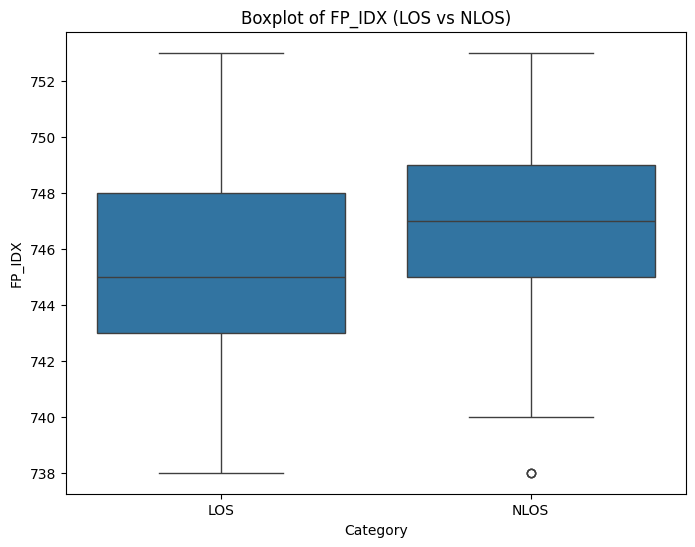

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Category", y="FP_IDX", data=df_clean_filtered)
plt.title("Boxplot of FP_IDX (LOS vs NLOS)")
plt.show()

##### **1.2.4 - Target Variable: FP_AMP1, FP_AMP2**, **FP_AMP3**

**Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

For FP_AMP1, 

In [13]:
# Calculate the Range using IQR for FP_AMP1
Q1_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.25)
Q3_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.75)
IQR_FP_AMP1 = Q3_FP_AMP1 - Q1_FP_AMP1
lower_bound_FP_AMP1 = Q1_FP_AMP1 - 1.5 * IQR_FP_AMP1
upper_bound_FP_AMP1 = Q3_FP_AMP1 + 1.5 * IQR_FP_AMP1

# Identify outliers
outliers_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] < lower_bound_FP_AMP1)
    | (df_clean["FP_AMP1"] > upper_bound_FP_AMP1)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] >= lower_bound_FP_AMP1)
    & (df_clean["FP_AMP1"] <= upper_bound_FP_AMP1)
]

# Print outliers
print("Outliers for 'FP_AMP1':\n", outliers_FP_AMP1)

Outliers for 'FP_AMP1':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


For FP_AMP2 ,

In [14]:
# Calculate the Range using IQR for FP_AMP2
Q1_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.25)
Q3_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.75)
IQR_FP_AMP2 = Q3_FP_AMP2 - Q1_FP_AMP2
lower_bound_FP_AMP2 = Q1_FP_AMP2 - 1.5 * IQR_FP_AMP2
upper_bound_FP_AMP2 = Q1_FP_AMP2 + 1.5 * IQR_FP_AMP2

# Identify outliers
outliers_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] < lower_bound_FP_AMP2)
    | (df_clean["FP_AMP2"] > upper_bound_FP_AMP2)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] >= lower_bound_FP_AMP2)
    & (df_clean["FP_AMP2"] <= upper_bound_FP_AMP2)
]

# Print outliers
print("Outliers for 'FP_AMP2':\n", outliers_FP_AMP2)

Outliers for 'FP_AMP2':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


For FP_AMP3 ,

In [15]:
# Calculate the Range using IQR for FP_AMP3
Q1_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.25)
Q3_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.75)
IQR_FP_AMP3 = Q3_FP_AMP3 - Q1_FP_AMP3
lower_bound_FP_AMP3 = Q1_FP_AMP3 - 1.5 * IQR_FP_AMP3
upper_bound_FP_AMP3 = Q1_FP_AMP3 + 1.5 * IQR_FP_AMP3

# Identify outliers
outliers_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] < lower_bound_FP_AMP3)
    | (df_clean["FP_AMP3"] > upper_bound_FP_AMP3)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] >= lower_bound_FP_AMP3)
    & (df_clean["FP_AMP3"] <= upper_bound_FP_AMP3)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers_FP_AMP3)

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
104     0.0   5.08   745.0   2922.0  15891.0  19129.0         80.0   9962.0   
123     0.0   1.40   750.0  16026.0  20343.0  19026.0         52.0  12543.0   
145     0.0   5.69   746.0   4278.0  17974.0  20245.0         48.0   9526.0   
185     0.0   1.98   746.0  12539.0  20207.0  19131.0         52.0  15467.0   
365     1.0   6.91   746.0   2318.0  19454.0  20296.0         60.0  23903.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41757   1.0   0.54   751.0   7203.0  19603.0  19507.0        160.0  11759.0   
41829   0.0   4.74   748.0   9000.0  15539.0  19426.0         68.0  10231.0   
41843   0.0   3.47   744.0   7574.0  19104.0  20218.0         52.0  11691.0   
41904   0.0   2.05   749.0   7766.0  18756.0  19044.0         60.0   9430.0   
41953   0.0   0.98   745.0  12354.0  11519.0  19650.0         48.0  15739.0   

       MAX_NOISE  RXPACC  .

After removing the outliers, we combine FP_AMP1, FP_AMP2, and FP_AMP3 into one DataFrame

In [16]:
# Combining multiplte dataframe in to one DataFrame
df_filtered = pd.DataFrame(
    {
        "FP_AMP1": df_clean_filtered_FP_AMP1["FP_AMP1"],
        "FP_AMP2": df_clean_filtered_FP_AMP2["FP_AMP2"],
        "FP_AMP3": df_clean_filtered_FP_AMP3["FP_AMP3"],
    }
)

# Reshape the data for the violin plot
df_filtered_melted = df_filtered.melt(var_name="Feature", value_name="Value")

**Data Vizualization**

After combining all into one DataFrame, we will plot a **violin graph** to illustrate the spread and median of **FP_AMP1**, **FP_AMP2**, and **FP_AMP3**, as their ranges are similar.

From the graph, we can see that these features have similar ranges, spread, and median. However, the median and spread for **FP_AMP1** are slightly higher than those of **FP_AMP2** and **FP_AMP3**, suggesting that **FP_AMP1** has slightly more variation or a higher central tendency compared to the other two.

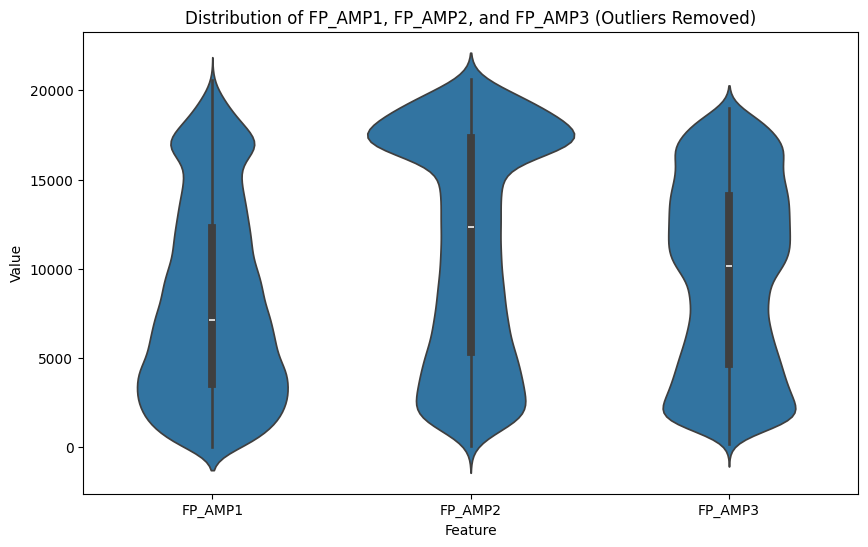

In [17]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Feature", y="Value", data=df_filtered_melted)

plt.title("Distribution of FP_AMP1, FP_AMP2, and FP_AMP3 (Outliers Removed)")
plt.show()

##### **1.2.5 - Target Variable: STDEV_NOISE**


For **STDEV_NOISE**, we will plot a strip plot to gain a better understanding of the distribution. The strip plot below illustrates the distribution of **STDEV_NOISE** with labels 0.0 and 1.0.

From the graph, we can observe that the 0.0 label has a lower **STDEV_NOISE** value compared to 1.0, indicating that the noise is more consistent in **LOS** (Line-of-Sight) than in **NLOS** (Non-Line-of-Sight).

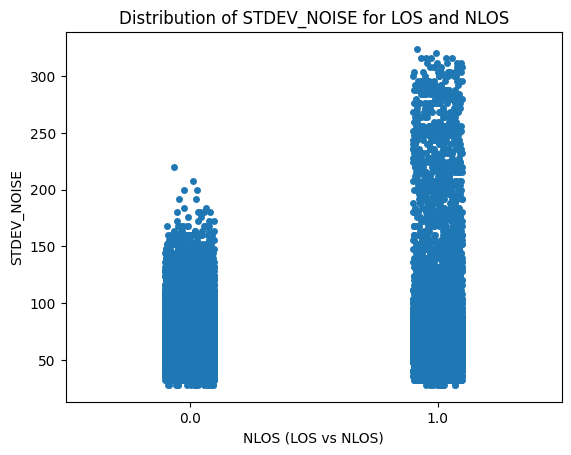

In [18]:
sns.stripplot(data=df_clean, x="NLOS", y="STDEV_NOISE", jitter=True)
plt.title("Distribution of STDEV_NOISE for LOS and NLOS")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("STDEV_NOISE")
plt.show()

##### **1.2.6 - Target Variable: CIR_PWR**

**Identifying and Removing Outliers**

We be removing outliners Using IQR (Interquartile Range): 

1. Calculate IQR and Identify Outliers

In [19]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for CIR_PWR
Q1_CIR_PWR = df_clean["CIR_PWR"].quantile(0.25)
Q3_CIR_PWR = df_clean["CIR_PWR"].quantile(0.75)

# Calculate the Interquartile Range (IQR) for CIR_PWR
IQR_CIR_PWR = Q3_CIR_PWR - Q1_CIR_PWR

# Calculate lower and upper bounds for outliers
lower_bound_CIR_PWR = Q1_CIR_PWR - 1.5 * IQR_CIR_PWR
upper_bound_CIR_PWR = Q3_CIR_PWR + 1.5 * IQR_CIR_PWR

# Identify outliers in CIR_PWR based on the calculated bounds
outliers_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] < lower_bound_CIR_PWR)
    | (df_clean["CIR_PWR"] > upper_bound_CIR_PWR)
]

2. Filter and Clean Data

In [20]:
# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] >= lower_bound_CIR_PWR)
    & (df_clean["CIR_PWR"] <= upper_bound_CIR_PWR)
]

# Print outliers
print("Outliers for 'CIR_PWR':\n", outliers_CIR_PWR)

Outliers for 'CIR_PWR':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
34      1.0   6.35   746.0  11146.0  10502.0   6624.0         60.0  21115.0   
56      0.0   2.12   747.0  13091.0  16349.0  11204.0        120.0  29570.0   
67      1.0   6.31   750.0  13805.0  19543.0  11380.0         64.0  31759.0   
71      1.0   6.68   745.0  13068.0   9016.0   5174.0         68.0  23124.0   
75      0.0   5.96   748.0  12532.0   8788.0  15810.0        128.0  25006.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41748   1.0   7.64   744.0    248.0  14006.0  12489.0         64.0  22825.0   
41834   0.0   5.09   750.0   8443.0  16866.0  11160.0         68.0  21287.0   
41871   0.0   3.07   746.0   5715.0  10261.0  12889.0         84.0  29942.0   
41922   0.0   1.67   746.0  10780.0  18043.0  14167.0        136.0  26737.0   
41974   1.0   7.59   747.0    108.0  17802.0  17768.0         52.0  24454.0   

       MAX_NOISE  RXPACC  

**Data Vizualization**

After removing the outliers, we will plot a histogram to better understand the distribution of **CIR_PWER** values. T

The histogram below illustrates the spread of values for **CIR_PWER** with labels 0.0 and 1.0. Based on this graph, we can see that the distributions for XLOS and NLOS statuses are similar for **CIR_PWER**, but **NLOS** has a wider spread of values.

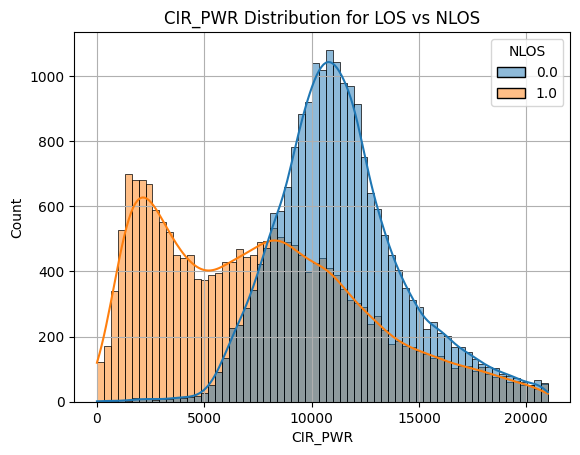

In [21]:
sns.histplot(data=df_clean_filtered_CIR_PWR, x="CIR_PWR", hue="NLOS", kde=True)
plt.title("CIR_PWR Distribution for LOS vs NLOS")
plt.xlabel("CIR_PWR")
plt.ylabel("Count")
plt.grid(True)
plt.show()

##### **1.2.7 - Target Variable: MAX_NOISE**

For **MAX_NOISE**, we will plot a violin plot to better understand the distribution and observe the variation in noise. The plot below illustrates the distribution of MAX_NOISE with labels 0.0 and 1.0.

From the graph, we can observe how the noise varies between LOS (Line-of-Sight) and NLOS (Non-Line-of-Sight), highlighting the differences in their noise patterns.

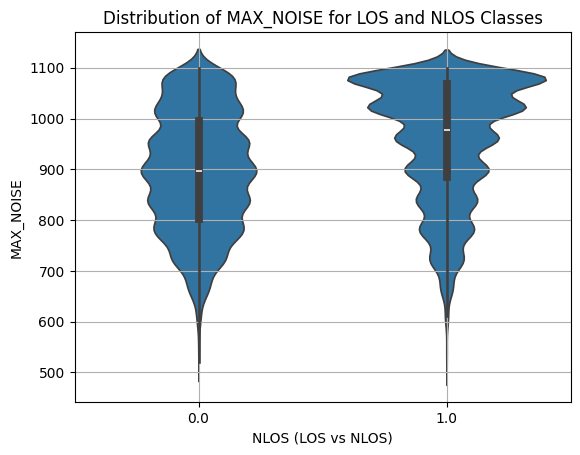

In [22]:
df_clean_filtered = df_clean[
    (df_clean["MAX_NOISE"] >= 500) & (df_clean["MAX_NOISE"] < 1100)
]

sns.violinplot(data=df_clean_filtered, x="NLOS", y="MAX_NOISE")
plt.title("Distribution of MAX_NOISE for LOS and NLOS Classes")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("MAX_NOISE")
plt.grid(True)
plt.show()

##### **1.2.8 - Target Variable: RXPACC**

**Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

Identify Outliers Using IQR for RXPACC

In [23]:
# Filter the data based on specific RXPACC values (between 500 and 1100)
df_clean_filtered_RXPACC = df_clean[
    (df_clean["RXPACC"] >= 500) & (df_clean["RXPACC"] < 1100)
]

print(df_clean_filtered_RXPACC)

       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
5       1.0   5.04   743.0   6490.0  12580.0   9741.0         92.0   3870.0   
6       1.0   4.82   750.0   9569.0  14115.0   9875.0         76.0  10179.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41985   1.0   3.22   746.0     35.0  12454.0  16598.0         80.0  11674.0   
41989   1.0   6.95   745.0   7356.0   7367.0   5727.0         64.0   3491.0   
41993   0.0   3.62   750.0   7650.0   8469.0   8684.0         64.0   9906.0   
41994   1.0   5.16   742.0   3132.0   3137.0   1868.0         76.0   3573.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   

       MAX_NOISE  RXPACC  ...  CIR1006  CIR1007  CI

Next, we will remove columns that are not necessary for plotting the graph. This will help streamline the dataset, ensuring that we only work with the relevant features needed for visualization.

In [24]:
# List of columns to exclude
columns_to_exclude = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "CIR_PWR",
    "MAX_NOISE",
]

# Remove the CIR_[Number] columns using regex
columns_to_exclude += [
    col for col in df_clean_filtered_RXPACC.columns if col.startswith("CIR")
]
df_clean_copy = df_clean_filtered_RXPACC.drop(columns=columns_to_exclude)


print(df_clean_copy)

       NLOS  RANGE  STDEV_NOISE  RXPACC   CH  FRAME_LEN  PREAM_LEN  BITRATE  \
0       1.0   6.18        240.0  1024.0  2.0       39.0     1024.0    110.0   
1       1.0   4.54         68.0  1024.0  2.0       39.0     1024.0    110.0   
2       1.0   4.39         52.0  1024.0  2.0       27.0     1024.0    110.0   
5       1.0   5.04         92.0  1024.0  2.0       39.0     1024.0    110.0   
6       1.0   4.82         76.0  1024.0  2.0       39.0     1024.0    110.0   
...     ...    ...          ...     ...  ...        ...        ...      ...   
41985   1.0   3.22         80.0  1024.0  2.0       27.0     1024.0    110.0   
41989   1.0   6.95         64.0  1024.0  2.0       27.0     1024.0    110.0   
41993   0.0   3.62         64.0   707.0  2.0       39.0     1024.0    110.0   
41994   1.0   5.16         76.0  1024.0  2.0       39.0     1024.0    110.0   
41998   0.0   3.17         64.0   789.0  2.0       39.0     1024.0    110.0   

       PRFR  
0      64.0  
1      64.0  
2      64

**Data Vizualization**

For **RXPACC** , we will plot a **KDE plot** to compare the distribution of **RXPACC** for **LOS (0.0)** and **NLOS (1.0)** classes. The plot helps highlight the density of **RXPACC** values, making it easy to spot any differences.

From the graph, we can see that **NLOS** has a more concentrated distribution of **RXPACC** values, while **LOS** shows a wider spread.

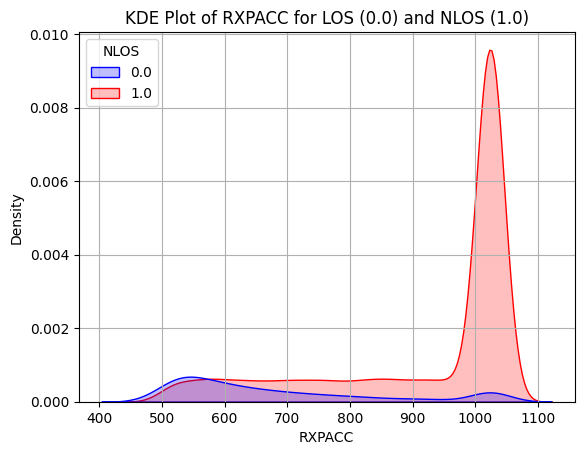

In [25]:
sns.kdeplot(
    data=df_clean_copy, x="RXPACC", hue="NLOS", fill=True, palette={0: "blue", 1: "red"}
)
plt.title("KDE Plot of RXPACC for LOS (0.0) and NLOS (1.0)")
plt.xlabel("RXPACC")
plt.ylabel("Density")
plt.grid(True)
plt.show()

##### **1.2.9 - Target Variable: FRAME_LEN**

**Count Occurrences of Values**

In [26]:
count_framelen = df_clean["FRAME_LEN"].value_counts()
print(count_framelen)

FRAME_LEN
39.0    23806
27.0    18193
29.0        1
Name: count, dtype: int64


**Visualizing the Data**

For **FRAME_LEN**, we will plot a bar chart showing the count distribution, which allows us to see how the values are spread across the dataset.

From this graph, we can observe that **39.0** appears the most frequently, followed by **27.0**, with **29.0** being very rare in the dataset.`

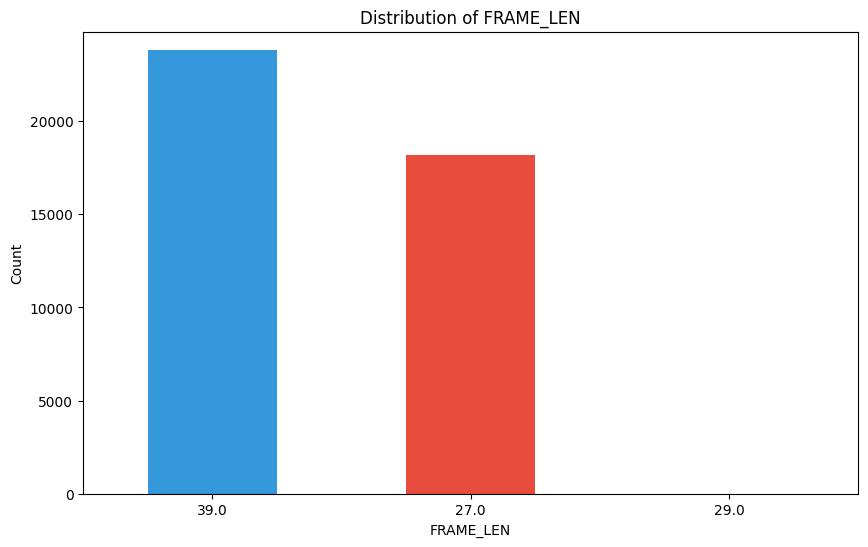

In [27]:
plt.figure(figsize=(10, 6))
count_framelen.plot.bar(color=["#3498db", "#e74c3c", "#f39c12"])
plt.title("Distribution of FRAME_LEN")
plt.ylabel("Count")
plt.xlabel("FRAME_LEN")
plt.xticks(rotation=0)

plt.yscale("linear")
plt.ylim(0, count_framelen.max() + 1000)

plt.show()

##### **1.2.10 - Target Variable: PREAM_LEN**

**Count Occurrences of Values**

In [28]:
count_PREAM_LEN = df_clean["PREAM_LEN"].value_counts()
print(count_PREAM_LEN)

PREAM_LEN
1024.0    40443
1536.0     1557
Name: count, dtype: int64


**Data Vizualization**

For **PREAM_LEN**, we will plot a bar chart showing the count distribution, which allows us to see how the values are spread across the dataset.

From this graph, we can observe that **1024.0** is overwhelmingly more common than **1536.0**, with **1024.0** making up the vast majority of the dataset.

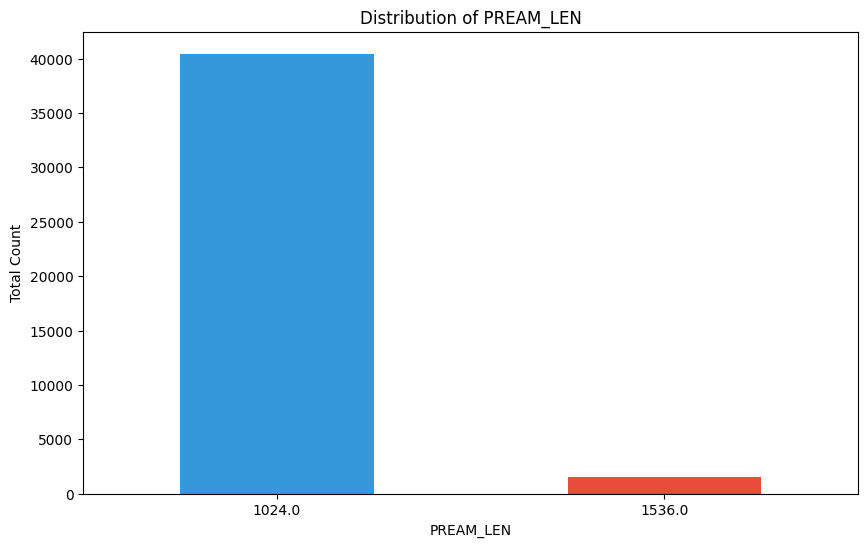

In [29]:
plt.figure(figsize=(10, 6))
count_PREAM_LEN.plot.bar(color=["#3498db", "#e74c3c"])
plt.title("Distribution of PREAM_LEN")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.show()

##### **1.2.1.11 - Target Variable: PRFR and BITRATE**

**Count Occurrences of Values**

In [30]:
# For 'PRFR' values
count_PRFR = df_clean["PRFR"].value_counts()

# For 'BITRATE' values
count_BITRATE = df_clean["BITRATE"].value_counts()

**Data Vizualization**

Combine and Plot the Distribution of 'PRFR' and 'BITRATE'

After counting the Occurense for PRFR and BITRATE, the graph will display side-by-side bars showing their total count occurrences. Since the columns have fixed categories, the graph will provide a clear comparison of how each category in PRFR and BITRATE is distributed.

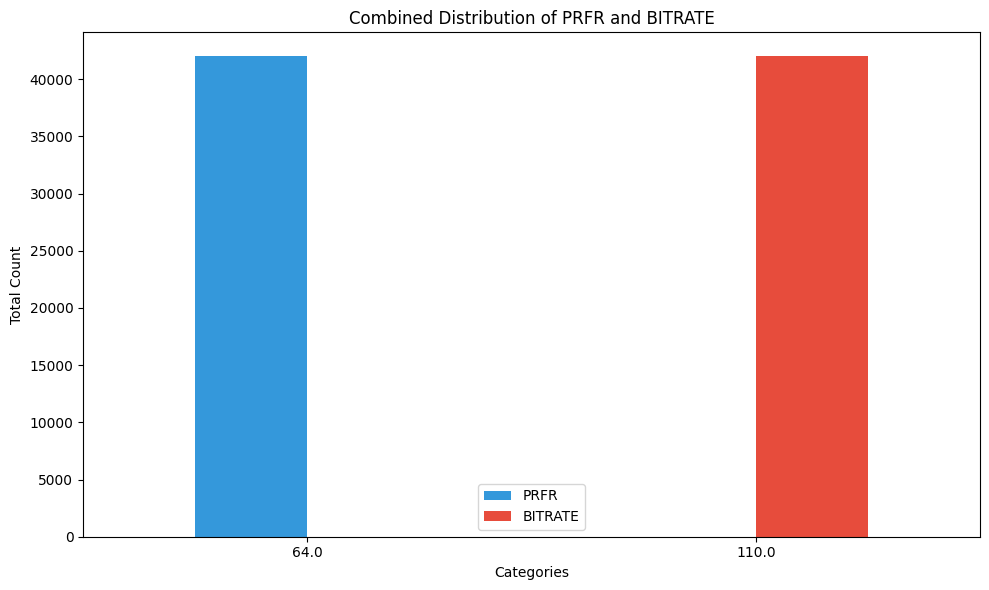

In [31]:
combined_df = pd.DataFrame(
    {"PRFR": count_PRFR, "BITRATE": count_BITRATE, "BITRATE": count_BITRATE}
).fillna(
    0
)  # combine

combined_df.plot(kind="bar", figsize=(10, 6), color=["#3498db", "#e74c3c"])

plt.title("Combined Distribution of PRFR and BITRATE")
plt.ylabel("Total Count")
plt.xlabel("Categories")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##### **1.2.1.12 - Target Variable: RANGE**

**Identifying and Removing Outliers**

We be removing outliners Using IQR (Interquartile Range): 

In [32]:
Q1_RANGE = df_clean["RANGE"].quantile(0.25)
Q3_RANGE = df_clean["RANGE"].quantile(0.75)
IQR_RANGE = Q3_RANGE - Q1_RANGE
lower_bound_RANGE = Q1_RANGE - 1.5 * IQR_RANGE
upper_bound_RANGE = Q3_RANGE + 1.5 * IQR_RANGE

# Identify outliers
outliers_RANGE = df_clean[
    (df_clean["RANGE"] < lower_bound_RANGE) | (df_clean["RANGE"] > upper_bound_RANGE)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_RANGE = df_clean[
    (df_clean["RANGE"] >= lower_bound_RANGE) & (df_clean["RANGE"] <= upper_bound_RANGE)
]

print(df_clean_filtered_RANGE)

       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09   745.0   1106.0   6951.0   6283.0         88.0  10076.0   
41996   0.0   2.18   744.0  14870.0  13482.0   8864.0         44.0  12604.0   
41997   0.0   1.25   748.0  18329.0  17722.0  10731.0         60.0  10192.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   
41999   1.0   7.24   743.0  15428.0  16758.0  10250.0         60.0  17738.0   

       MAX_NOISE  RXPACC  ...  CIR1006  CIR1007  CI

**Data Vizualization**

For **RANGE**, we will plot a box plot to understand its distribution and identify outliers. 

From the graph, we can observe that **RANGE** has a wide spread with some potential outliers at the higher end.

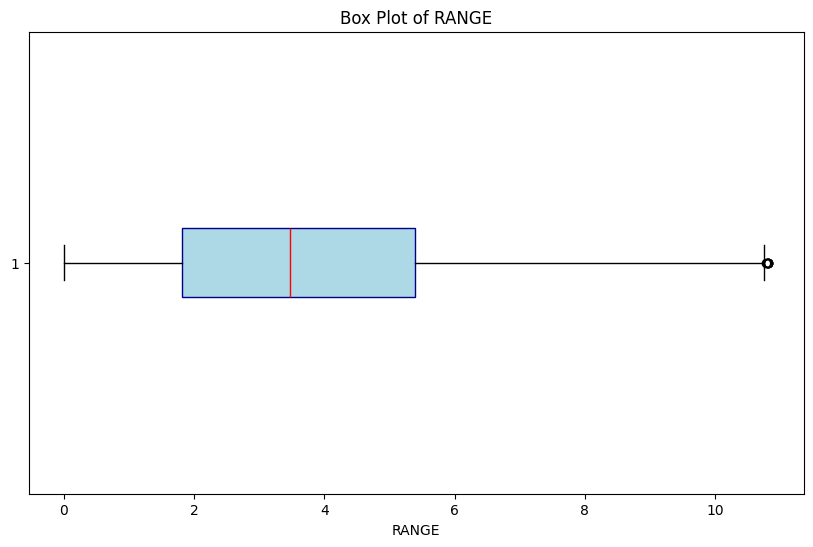

In [33]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    df_clean_filtered_RANGE["RANGE"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="darkblue"),
    medianprops=dict(color="red"),
)
plt.title("Box Plot of RANGE")
plt.xlabel("RANGE")
plt.show()

After having a better understanding of the features in the dataset using visualization, next we need to identify which features have the most impact on predicting the target variable. This allows us to focus on the most relevant features, improving model performance and interpretability.

We be using different technique:


#### **1.3 - Feature Evaluation and Relationship Analysis**

##### **1.3.1 -Feature Evaluation and Preprocessing**

###### **1.3.1.1 - Correlation Matrix**

Firstly we be calculating the  **Correlation Matrix**, we will plot a heatmap to gain a better understanding of the relationships between different features. The heatmap below illustrates the correlation between each feature, with color intensity representing the strength of the relationship.

From the graph, we can observe that **RXPACC** has a strong positive correlation with **RANGE**, while **FP_AMP1**, **FP_AMP2**, and **FP_AMP3** show negative correlations with **RANGE**, indicating their potential influence on the target variable.

In [34]:
features = [
    "RANGE",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

correlation_matrix = df_clean[features].corr()
print(correlation_matrix)

                RANGE    FP_IDX   FP_AMP1   FP_AMP2   FP_AMP3  STDEV_NOISE  \
RANGE        1.000000 -0.321809 -0.459196 -0.479689 -0.459521     0.089544   
FP_IDX      -0.321809  1.000000  0.318126  0.442985  0.460630    -0.040994   
FP_AMP1     -0.459196  0.318126  1.000000  0.594008  0.459750    -0.058817   
FP_AMP2     -0.479689  0.442985  0.594008  1.000000  0.886110    -0.099765   
FP_AMP3     -0.459521  0.460630  0.459750  0.886110  1.000000    -0.084635   
STDEV_NOISE  0.089544 -0.040994 -0.058817 -0.099765 -0.084635     1.000000   
CIR_PWR     -0.263718  0.316600  0.341158  0.394945  0.400304    -0.033533   
MAX_NOISE   -0.260065  0.106560  0.235854  0.194410  0.184564     0.828995   
RXPACC       0.626349 -0.382566 -0.529544 -0.622441 -0.594305     0.240308   
FRAME_LEN   -0.048082  0.000497 -0.004481 -0.000681 -0.000004    -0.050907   
PREAM_LEN    0.390055 -0.229423 -0.171689 -0.221676 -0.215839     0.087069   

              CIR_PWR  MAX_NOISE    RXPACC  FRAME_LEN  PREAM_LE

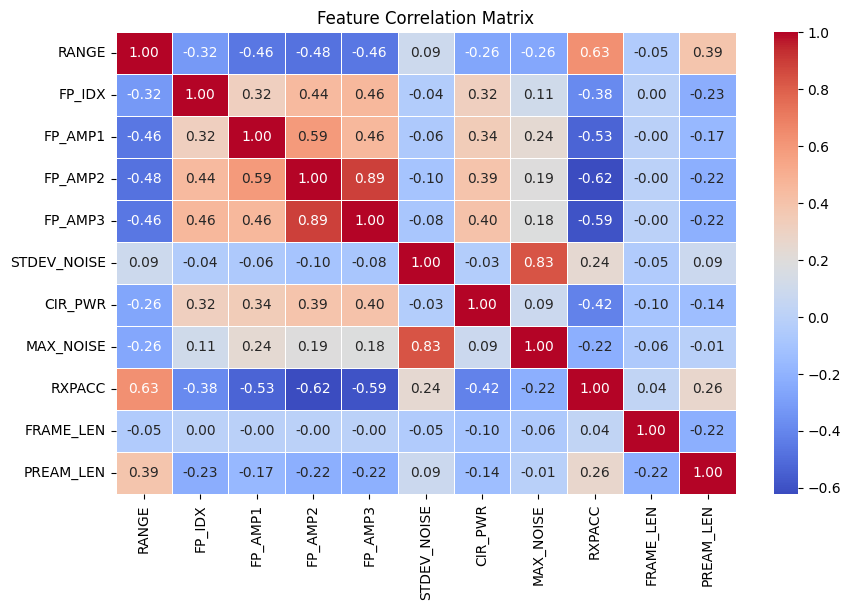

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

###### **1.3.1.2 - Mutual Information**

Secondly, we will calculate the **Mutual Information** to assess the relationship between each feature and the target variable **RANGE**. We will plot a bar chart to visualize the mutual information scores where higher scores indicate more significant features for prediction.

From the graph, we can observe that **RXPACC** has the highest mutual information score  making it the most important feature for predicting **RANGE**. Other features such as **MAX_NOISE** and **CIR_PWR** also have notable scores  suggesting their relevance. On the other hand, **FRAME_LEN** has a low score which indicating that it might have less influence on the target variable.

In [36]:
# import libraries
try:
    from sklearn.feature_selection import mutual_info_regression

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [37]:
# mutual information => (to check the relationship between the features)

# Features
features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Define X as features set
X = df_clean[features]

# Define target variable
y = df_clean["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

Mutual Information Scores (in descending order):
RXPACC         0.383328
MAX_NOISE      0.217983
CIR_PWR        0.180716
FP_AMP2        0.152429
FP_AMP1        0.149733
FP_AMP3        0.137517
STDEV_NOISE    0.113432
FP_IDX         0.083262
PREAM_LEN      0.074203
FRAME_LEN      0.002859
dtype: float64


**Visualizing the Data**

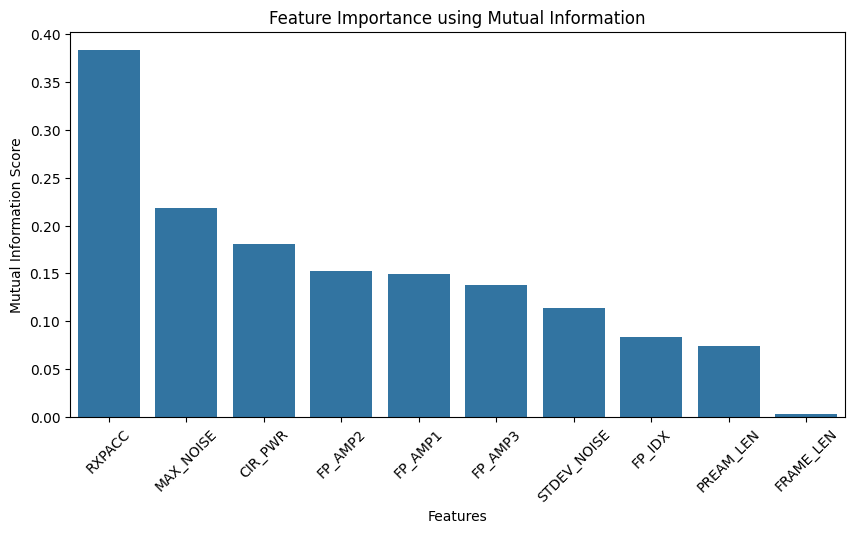

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values)
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

###### **1.3.1.3 - Normalization**

Thirdly, we performed **Normalization** using **MinMaxScaler** to scale feature values between **0 and 1**. The histogram below shows the distribution of scaled features, ensuring they fall within the same range.

Most features are **well-scaled**, but some may show **skewness** or **concentration** at one end, indicating the need for further transformations. The histogram also highlights potential **outliers** that could impact model performance.

Normalization helps ensure **equal contribution** of all features, improving the **accuracy** and **stability** of the classifier.

In [39]:
# import libraries

try:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [40]:
X = df_clean.drop(columns=["NLOS"])

y = df_clean["NLOS"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

print(X_train)

          RANGE    FP_IDX   FP_AMP1   FP_AMP2   FP_AMP3  STDEV_NOISE  \
0      0.228775  0.248227  0.113348  0.177954  0.116969     0.135135   
1      0.229423  0.290780  0.328228  0.344126  0.291515     0.108108   
2      0.255995  0.248227  0.114466  0.083208  0.048455     0.175676   
3      0.070642  0.290780  0.141503  0.207362  0.108583     0.108108   
4      0.090084  0.297872  0.358230  0.499440  0.354389     0.094595   
...         ...       ...       ...       ...       ...          ...   
33595  0.177576  0.290780  0.646389  0.879741  0.667239     0.000000   
33596  0.303305  0.226950  0.058352  0.083889  0.134183     0.135135   
33597  0.088788  0.269504  0.328957  0.783047  0.848406     0.040541   
33598  0.362281  0.290780  0.522636  0.860899  0.552869     0.162162   
33599  0.267660  0.276596  0.767809  0.621793  0.449926     0.108108   

        CIR_PWR  MAX_NOISE    RXPACC   CH  ...   CIR1006   CIR1007   CIR1008  \
0      0.184783   0.150854  0.965517  0.0  ...  0.18793

**Visualizing the Data**

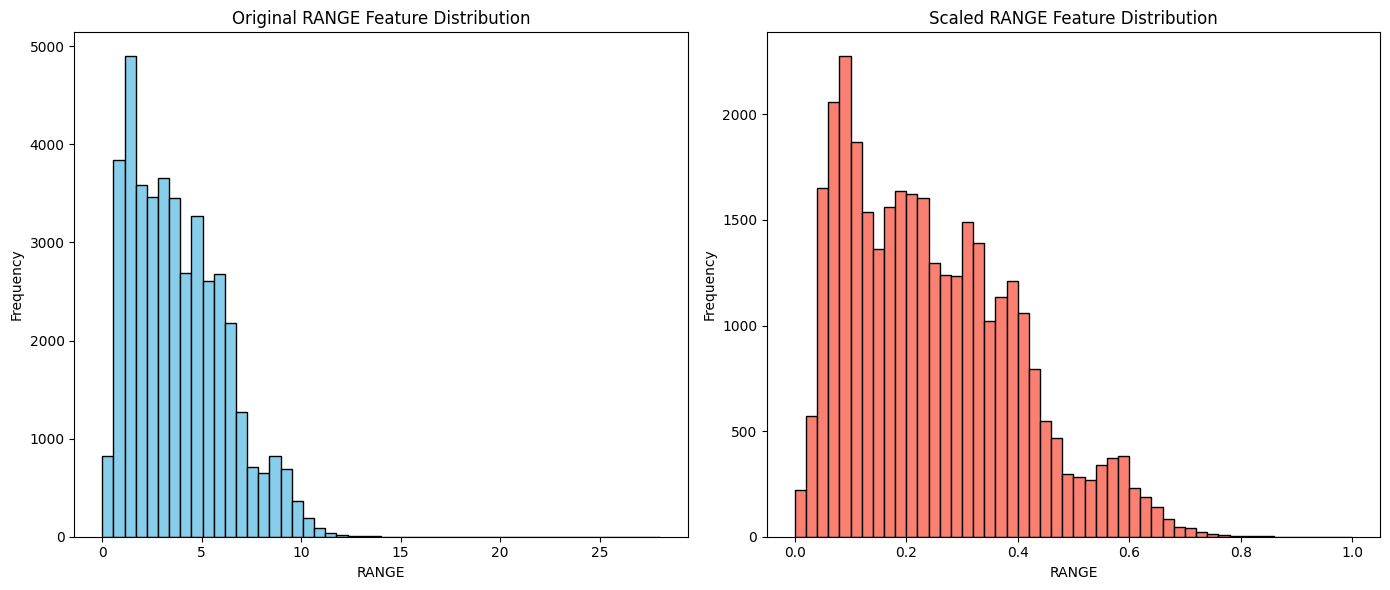

In [41]:
# Plot histograms for the first feature (RANGE) before and after scaling
plt.figure(figsize=(14, 6))

# Original data (before scaling)
plt.subplot(1, 2, 1)
plt.hist(X["RANGE"], bins=50, color="skyblue", edgecolor="black")
plt.title("Original RANGE Feature Distribution")
plt.xlabel("RANGE")
plt.ylabel("Frequency")

# Scaled data (after MinMaxScaler)
plt.subplot(1, 2, 2)
plt.hist(X_train["RANGE"], bins=50, color="salmon", edgecolor="black")
plt.title("Scaled RANGE Feature Distribution")
plt.xlabel("RANGE")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

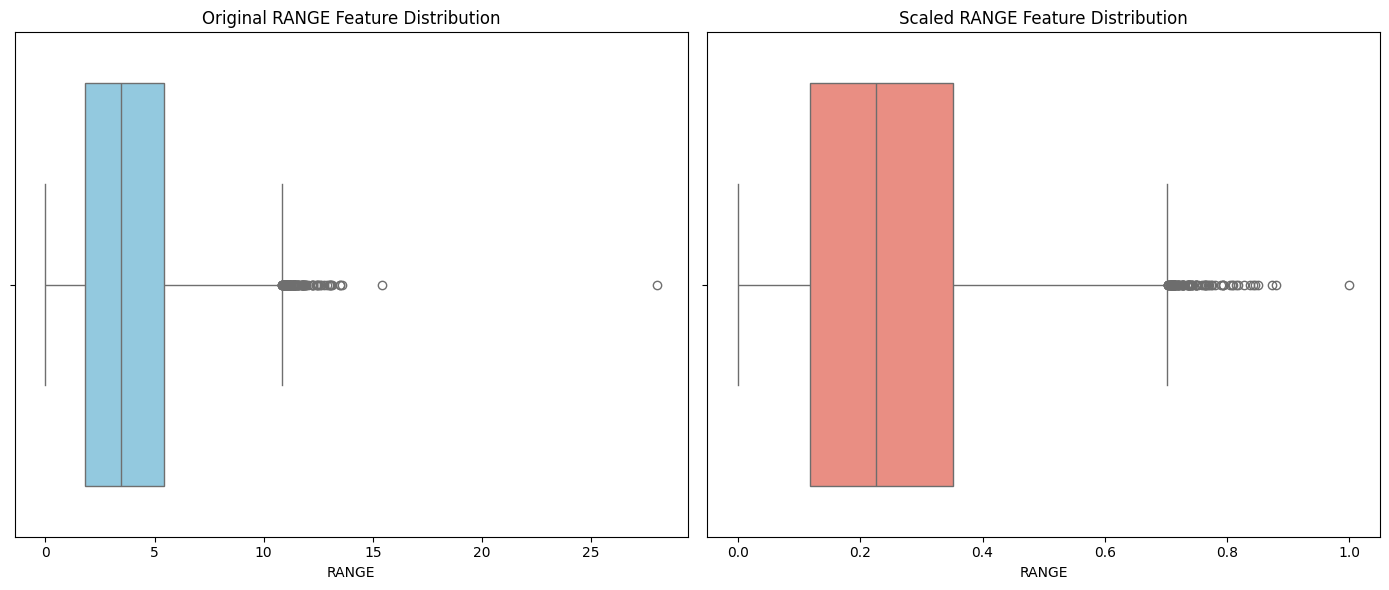

In [42]:
plt.figure(figsize=(14, 6))

# Original data (before scaling)
plt.subplot(1, 2, 1)
sns.boxplot(x=X["RANGE"], color="skyblue")
plt.title("Original RANGE Feature Distribution")

# Scaled data (after MinMaxScaler)
plt.subplot(1, 2, 2)
sns.boxplot(x=X_train["RANGE"], color="salmon")
plt.title("Scaled RANGE Feature Distribution")

plt.tight_layout()
plt.show()

###### **1.3.1.4 - Principal Component Analysis (PCA)**

Lastly, we performed **PCA** to reduce the number of CIR features while retaining key information. PCA transforms the original features into principal components, which capture the most important patterns in the data. The first 14 components explain 95% of the variance, with the 15th capturing the remaining variance. This reduces the dataset's complexity while preserving essential details for further analysis and modeling.

In [43]:
# Import  libraries
try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


1. Selecting CIR Features from the Cleaned Data


In [44]:
# CIR Features List
cir_features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

X_cir = df_clean[cir_features]

2. Standardization of Data

In [45]:
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)

3. Applying PCA
To retain 95% of the variance by selecting the number of components.

In [46]:
# Applying PCA to retain 95% of the variance
pca = PCA(n_components=0.95)
X_cir_pca = pca.fit_transform(X_cir_scaled)

4. Checking the Shape of Transformed Data and Converting PCA Data to DataFrame

In [47]:
# Extract the number of PCA components selected
reduced_features = X_cir_pca.shape[1]
print(
    f"New shape after PCA: {X_cir_pca.shape} (Reduced to {reduced_features} components)"
)

# Naming the PCA components
pca_feature_names = [f"PCA_{i}" for i in range(reduced_features)]
df_pca = pd.DataFrame(X_cir_pca, columns=pca_feature_names)

# Display variance explained by each component
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio for each component:", explained_variance_ratio)
print("Cumulative Explained Variance:", cumulative_variance)

New shape after PCA: (42000, 8) (Reduced to 8 components)
Explained Variance Ratio for each component: [0.36251239 0.18473292 0.11825062 0.07951557 0.07015036 0.06775219
 0.05697488 0.0453346 ]
Cumulative Explained Variance: [0.36251239 0.54724531 0.66549593 0.7450115  0.81516186 0.88291405
 0.93988893 0.98522353]


5. Replacing Original Features with PCA Features


In [48]:
# Drop original CIR features as they are now represented by PCA components
df_clean = df_clean.drop(columns=cir_features, errors="ignore")

# Concatenate the PCA components back into the cleaned DataFrame
df_clean = pd.concat([df_clean, df_pca], axis=1)

df_pca["PCA_0"]

0       -0.007402
1       -2.916797
2       -2.731927
3        1.943603
4        2.542737
           ...   
41995   -0.614662
41996    0.830474
41997    2.059664
41998    0.850061
41999    1.402571
Name: PCA_0, Length: 42000, dtype: float64

Visualizing the Data

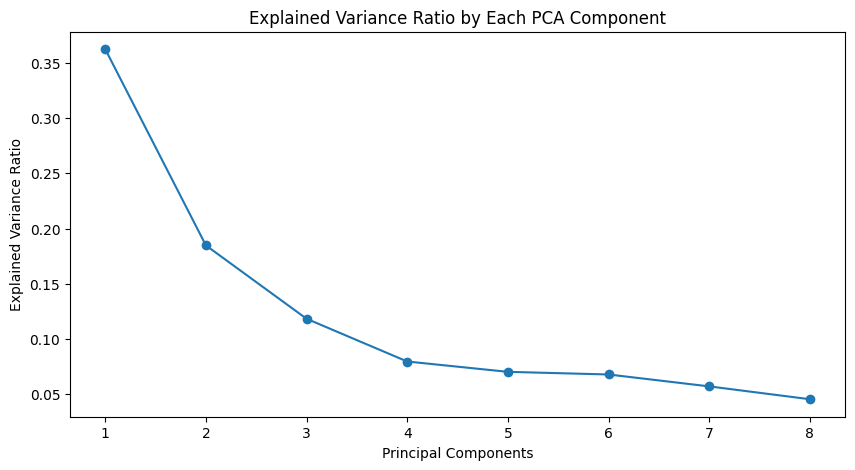

In [49]:
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o"
)
plt.title("Explained Variance Ratio by Each PCA Component")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

##### **1.3.2 - Feature Importance Ranking**
 

In [50]:
#Correlaition Matrix
correlation_with_target = correlation_matrix["RANGE"].abs().sort_values(ascending=False)
print("Feature Importance based on Correlation with Target:")
print(correlation_with_target)


Feature Importance based on Correlation with Target:
RANGE          1.000000
RXPACC         0.626349
FP_AMP2        0.479689
FP_AMP3        0.459521
FP_AMP1        0.459196
PREAM_LEN      0.390055
FP_IDX         0.321809
CIR_PWR        0.263718
MAX_NOISE      0.260065
STDEV_NOISE    0.089544
FRAME_LEN      0.048082
Name: RANGE, dtype: float64


In [51]:
# Mutual Information
mi_scores_sorted = mi_scores.sort_values(ascending=False)
print("Feature Importance based on Mutual Information:")
print(mi_scores_sorted)

Feature Importance based on Mutual Information:
RXPACC         0.383328
MAX_NOISE      0.217983
CIR_PWR        0.180716
FP_AMP2        0.152429
FP_AMP1        0.149733
FP_AMP3        0.137517
STDEV_NOISE    0.113432
FP_IDX         0.083262
PREAM_LEN      0.074203
FRAME_LEN      0.002859
dtype: float64


In [52]:
# PCA
pca_component_contributions = pd.DataFrame(pca.components_, columns=cir_features)
pca_feature_importance = (
    pca_component_contributions.abs().sum(axis=0).sort_values(ascending=False)
)
print("Feature Importance based on PCA Contribution:")
print(pca_feature_importance)

Feature Importance based on PCA Contribution:
PREAM_LEN      2.481345
CIR_PWR        2.221162
FP_AMP1        2.191687
FP_IDX         2.063263
FRAME_LEN      2.014234
RXPACC         1.856791
FP_AMP3        1.643296
FP_AMP2        1.561408
MAX_NOISE      1.393537
STDEV_NOISE    1.331467
dtype: float64


**Ranking Features Based on Importance (1 is the most important)**

Based on the feature importance rankings, **`RXPACC`** emerges as the most important feature across all methods, with high correlation with the target and significant mutual information. **`PREAM_LEN`** stands out in PCA for its contribution to variance, while **`FP_AMP2`** and **`MAX_NOISE`** show strong importance across multiple methods. Features like **`FRAME_LEN`** and **`STDEV_NOISE`** are less influential, but still contribute to the overall data structure, particularly in PCA. These insights guide the focus on **`RXPACC`**, **`PREAM_LEN`**, and other key features for model improvement.

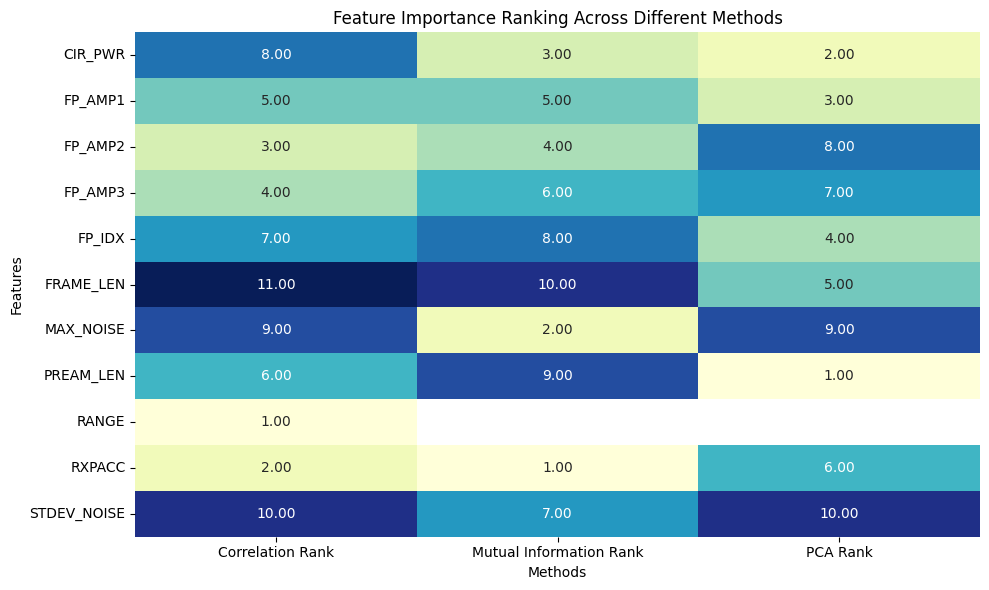

In [53]:
correlation_ranking = correlation_with_target.rank(ascending=False)
mi_ranking = mi_scores_sorted.rank(ascending=False)
pca_ranking = pca_feature_importance.rank(ascending=False)

# Combine rankings into a DataFrame
feature_ranking = pd.DataFrame(
    {
        "Correlation Rank": correlation_ranking,
        "Mutual Information Rank": mi_ranking,
        "PCA Rank": pca_ranking,
    }
)


# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(feature_ranking, annot=True, cmap="YlGnBu", fmt=".2f", cbar=False)
plt.title("Feature Importance Ranking Across Different Methods")
plt.xlabel("Methods")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## **2 - Data Mining & Splitting**


After feature evaluation, we divide the dataset into training and test sets to train the model and assess its performance on unseen data.

In [54]:
# import libaries
try:
    from sklearn.model_selection import train_test_split
    import numpy as np

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


First, we split the dataset into training and testing sets to maintains the same structure but improves readability.

### **2.4.1 - Data Minning**

In [55]:
# Remove CIR columns (PCA already reduced them)
df_clean = df_clean.loc[:, ~df_clean.columns.str.match(r"^CIR\d+$")]

# Drop unnecessary columns
columns_to_drop = ["FP_AMP2", "MAX_NOISE", "FRAME_LEN", "CH", "PRFR"]
df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

# Find all FP_AMP columns and compute the average
fp_amp_cols = df_clean.filter(like="FP_AMP").columns

if len(fp_amp_cols) > 0:
    df_clean["FP_AMP_AVG"] = df_clean[fp_amp_cols].mean(axis=1)
    df_clean = df_clean.drop(columns=fp_amp_cols, errors="ignore")

# Features (excluding 'NLOS' since it's the target)
X = df_clean.drop(columns=["NLOS"], errors="ignore")

# Target variable
y = df_clean["NLOS"]


### **2.4.2 - Data Splitting**

In [56]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print dataset shapes
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Testing Labels Shape: {y_test.shape}")

Training Features Shape: (33600, 10)
Testing Features Shape: (8400, 10)
Training Labels Shape: (33600,)
Testing Labels Shape: (8400,)


## **3 - Model Training & Model Evaluation**

Once the dataset has been divided into training and testing sets, we will proceed with training the model using the training data and a selection of algorithms. Using multiple algorithms allows us to compare their performance and choose the one that best suits the problem at hand. Different algorithms may capture different patterns in the data, and leveraging a variety of approaches can enhance the model's ability to generalize and improve accuracy on unseen data.


In [57]:
# import libaries
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.ensemble import RandomForestClassifier
    import itertools
    from sklearn.metrics import (
        roc_curve,
        roc_auc_score,
    )

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


#### **3.1 - Logistic Regression**

Firstly, we initializes a Logistic Regression model with specific hyperparameters and then trains the model on the scaled training data **(X_train_scaled)** to classify the target labels (y_train).

In [58]:
# import libaries
try:
    from sklearn.metrics import (
        auc,
        accuracy_score,
        classification_report,
        confusion_matrix,
    )
    from sklearn.model_selection import learning_curve
    from sklearn.model_selection import GridSearchCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [59]:
# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### **3.1.1 - Hyperparameter Tuning** 


To further enhance the model’s performance, we perform Hyperparameter Tuning to find the best combination of parameters. The optimal hyperparameters were penalty: 'l2', C: 0.1, solver: 'saga', and max_iter: 200, improving the model’s accuracy and efficiency.

In [60]:
# Define hyperparameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],  # Regularization strength
    "solver": ["liblinear", "lbfgs"],  # Solvers
    "max_iter": [1000, 2000],  # Max iterations
}

# Initialize Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(lr_model, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train_scaled, y_train)

# Best hyperparameters
best_lr_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}


##### **3.1.2 - Model Training and Testing (Description to be modify)** 

**Training and Test ROC-AUC** 

In [61]:
# Predict probabilities for training and test sets
y_train_pred_lr = best_lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_lr = best_lr_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC-AUC scores for both train and test sets
train_auc_lr = roc_auc_score(y_train, y_train_pred_lr)
test_auc_lr = roc_auc_score(y_test, y_test_pred_lr)

# Print AUC for train and test
print(
    f"Logistic Regression - Train ROC-AUC: {train_auc_lr:.4f}, Test ROC-AUC: {test_auc_lr:.4f}"
)

Logistic Regression - Train ROC-AUC: 0.9194, Test ROC-AUC: 0.9201


###### **3.1.3 - visualization graph** 

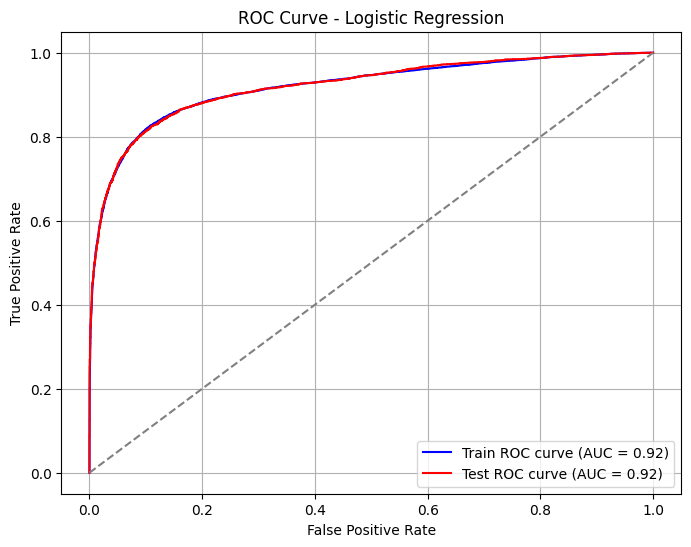

In [62]:
fpr_train_lr, tpr_train_lr, _ = roc_curve(y_train, y_train_pred_lr)
fpr_test_lr, tpr_test_lr, _ = roc_curve(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train_lr,
    tpr_train_lr,
    color="blue",
    label="Train ROC curve (AUC = {:.2f})".format(train_auc_lr),
)
plt.plot(
    fpr_test_lr,
    tpr_test_lr,
    color="red",
    label="Test ROC curve (AUC = {:.2f})".format(test_auc_lr),
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)

##### **3.1.3  - Model Evaluation (to be modify)**

To further assess the model's performance, we evaluate key metrics, including **accuracy, confusion matrix, and classification report**. The **Logistic Regression** model achieved an **accuracy of 0.8560**, indicating strong overall performance across both the training and test data.  

The **Confusion Matrix** provides further insights into the model's classification performance. The model correctly identified **3870 True Negatives** and **3320 True Positives**, while misclassifying **382 False Positives** and **828 False Negatives**. These values suggest that the model performs well but misses some **NLOS** instances.  

The **Classification Report** provides additional details on precision, recall, and f1-score. The **precision** for **LOS (0.0)** is **0.82**, while for **NLOS (1.0)** it is **0.90**, indicating that the model is slightly better at predicting **NLOS** instances correctly. The **recall** for **LOS (0.0)** is **0.91**, demonstrating strong identification of **LOS**, whereas the **recall** for **NLOS (1.0)** is **0.80**, meaning some **NLOS** cases are misclassified. The **f1-scores** for both classes are balanced, with **LOS (0.0) at 0.86** and **NLOS (1.0) at 0.85**, reflecting the model’s overall effectiveness.  

Overall, the model shows strong performance in distinguishing between **LOS** and **NLOS**. However, reducing **False Negatives** could further enhance its ability to identify **NLOS** instances.

To further assess the model's performance, we evaluate the **ROC-AUC** scores. The **Train ROC-AUC** score of **0.9185** and the **Test ROC-AUC** score of **0.9187** indicate that the Logistic Regression model performs consistently well across both the training and test data. These scores suggest strong generalization, as the values are almost identical, showing that the model is not overfitting.

The **Classification Report** provides further insights into the model's performance. The precision and recall for both classes are quite balanced, with **precision** for **LOS (0.0)** at **0.82** and **NLOS (1.0)** at **0.90**. The **recall** for **LOS (0.0)** is **0.91**, indicating good identification of **LOS** instances, while the **recall** for **NLOS (1.0)** is **0.80**, showing that the model misses a few **NLOS** instances. However, the **f1-scores** for both classes are **0.86**, indicating overall good performance for both classes.

Overall, the **ROC-AUC** values show that the model is effective at distinguishing between **LOS** and **NLOS**. The **classification report** supports this by showing a good balance in performance, especially in terms of precision, recall, and f1-scores.

In [63]:
# Predict using the best Logistic Regression model
y_pred_lr = best_lr_model.predict(X_test_scaled)

# Calculate accuracy of the Logistic Regression model
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Generate the confusion matrix for the Logistic Regression model
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# Print out the evaluation metrics for the Logistic Regression model
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Confusion Matrix:\n{conf_matrix_lr}")
print(
    f"Logistic Regression Classification Report:\n{classification_report(y_test, y_pred_lr)}"
)

Logistic Regression Accuracy: 0.8571
Logistic Regression Confusion Matrix:
[[3853  399]
 [ 801 3347]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      4252
         1.0       0.89      0.81      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



###### **3.1.3 - visualization graph (to be added)**


##### **3.1.4 - Evaluation and Performance of the Best Logistic Regression Model (description to be modify)**


After performing hyperparameter tuning, the model was evaluated to assess its performance. The evaluation focused on key metrics such as accuracy, precision, recall, and ROC-AUC on the test dataset, to determine the model’s ability to generalize to unseen data.


The optimized Logistic Regression model achieved an accuracy of 85.60%. It performed well in identifying NLOS, with 3871 True Negatives, but exhibited a higher False Negative rate for LOS (826).  Precision was higher for LOS (0.90), while recall was better for NLOS (0.91), suggesting a slight imbalance in the model's predictions.

To further evaluate the model, we make predictions on the test data and calculate key metrics such as accuracy and confusion matrix:


In [64]:
# Predict using the best Logistic Regression model on both training and testing data
y_train_pred_best_lr = best_lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_best_lr = best_lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC for the best Logistic Regression model
train_auc_best_lr = roc_auc_score(y_train, y_train_pred_best_lr)
test_auc_best_lr = roc_auc_score(y_test, y_test_pred_best_lr)

# Print evaluation metrics for the best Logistic Regression model
print(
    f"Best Logistic Regression - Train ROC-AUC: {train_auc_best_lr:.4f}, Test ROC-AUC: {test_auc_best_lr:.4f}"
)

Best Logistic Regression - Train ROC-AUC: 0.9194, Test ROC-AUC: 0.9201


###### **3.1.3 - visualization graph** 

**(description to be modify)** 

The ROC curve below visualizes the performance of the Best Logistic Regression model. With an AUC of 0.9187, the model demonstrates a strong ability to distinguish between LOS and NLOS classes. The curve significantly exceeds the random guessing baseline (the gray dashed line), indicating the model's high accuracy. The close proximity of the model's ROC AUC to 1.0 suggests that the model is highly effective at identifying both classes. However, there's always potential to fine-tune the model to improve performance further.


To further assess the model's performance, we evaluate key metrics, including **accuracy, confusion matrix, and classification report**. The **Logistic Regression** model achieved an **accuracy of 0.8560**, indicating strong overall performance across both the training and test data.  

The **Confusion Matrix** provides further insights into the model's classification performance. The model correctly identified **3870 True Negatives** and **3320 True Positives**, while misclassifying **382 False Positives** and **828 False Negatives**. These values suggest that the model performs well but misses some **NLOS** instances.  

The **Classification Report** provides additional details on precision, recall, and f1-score. The **precision** for **LOS (0.0)** is **0.82**, while for **NLOS (1.0)** it is **0.90**, indicating that the model is slightly better at predicting **NLOS** instances correctly. The **recall** for **LOS (0.0)** is **0.91**, demonstrating strong identification of **LOS**, whereas the **recall** for **NLOS (1.0)** is **0.80**, meaning some **NLOS** cases are misclassified. The **f1-scores** for both classes are balanced, with **LOS (0.0) at 0.86** and **NLOS (1.0) at 0.85**, reflecting the model’s overall effectiveness.  

Overall, the model shows strong performance in distinguishing between **LOS** and **NLOS**. However, reducing **False Negatives** could further enhance its ability to identify **NLOS** instances.

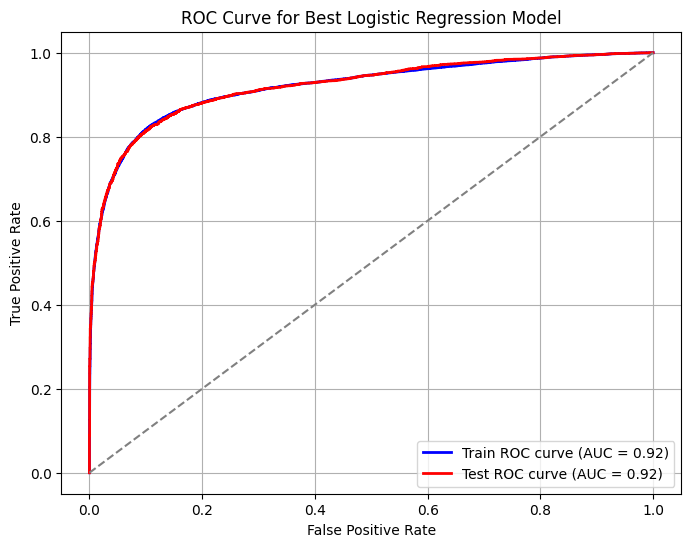

In [65]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_best_lr)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_best_lr)

train_auc = auc(fpr_train, tpr_train)
test_auc = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color="blue", lw=2, label=f"Train ROC curve (AUC = {train_auc:.2f})")
plt.plot(fpr_test, tpr_test, color="red", lw=2, label=f"Test ROC curve (AUC = {test_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Best Logistic Regression Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##### **3.1.5 - Confusion Matrix Visualization (description to be added)**

XXX

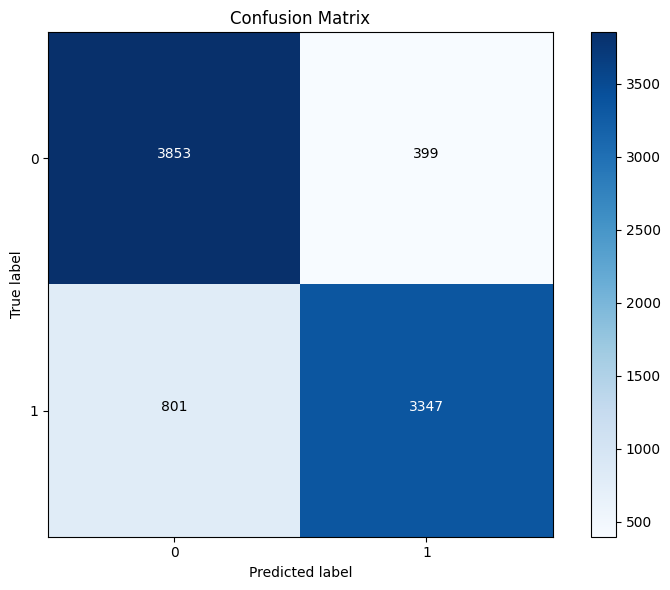

In [66]:
# Plot the confusion matrix for the best Logistic Regression model
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_lr, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Threshold to make text color readable
thresh = conf_matrix_lr.max() / 2.
for i, j in itertools.product(range(conf_matrix_lr.shape[0]), range(conf_matrix_lr.shape[1])):
    plt.text(j, i, format(conf_matrix_lr[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix_lr[i, j] > thresh else "black")
    
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


##### **3.1.6 - Conclusion: Performance of the Best Logistic Regression Mode (to be modify)**

In [67]:
# Final conclusion summarizing the performance
print("Conclusion:")
print(
    f"The best Logistic Regression model achieved a training ROC-AUC of {train_auc_best_lr:.4f} and a test ROC-AUC of {test_auc_best_lr:.4f}."
)
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_lr}")

Conclusion:
The best Logistic Regression model achieved a training ROC-AUC of 0.9194 and a test ROC-AUC of 0.9201.
Accuracy: 0.8571
Confusion Matrix:
[[3853  399]
 [ 801 3347]]


#### **3.2 - Support Vector Machine (SVM)**

First, the SVM model is initialized with probability output and trained on the training data to classify the target labels.

In [68]:
# import libaries
try:
    from sklearn.svm import SVC

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [69]:
svm_model = SVC(probability=True, random_state=42)

##### **3.2.1 - Hyperparameter Tuning** 

To further enhance the model's performance, we perform hyperparameter tunning to  optimize the performance of the SVM model by selecting the best combination of parameters. In this case, GridSearchCV was used to tune the C, gamma, and kernel hyperparameters.

In [70]:
# Define the parameter grid for tuning
param_grid = {
    "C": [0.1, 1, 10],  # Regularization parameter
    "kernel": ["linear"],  # Only linear kernel
}

# Set up GridSearchCV with the correct parameter grid and other settings
grid_search = GridSearchCV(
    svm_model,
    param_grid=param_grid,
    cv=2,  # 2-fold cross-validation
    n_jobs=-1,
    verbose=1,  # reduced verbosity
    scoring="roc_auc",  # Evaluation => ROC-AUC
)
grid_search.fit(X_train, y_train)
print(f"Grid Search Results: \n{grid_search.cv_results_}")

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Grid Search Results: 
{'mean_fit_time': array([13.91303885, 21.88513052, 46.87766182]), 'std_fit_time': array([0.46011984, 0.28246129, 0.40699017]), 'mean_score_time': array([1.33537805, 0.97828948, 0.94528258]), 'std_score_time': array([0.05368793, 0.00919139, 0.06925428]), 'param_C': masked_array(data=[0.1, 1.0, 10.0],
             mask=[False, False, False],
       fill_value=1e+20), 'param_kernel': masked_array(data=['linear', 'linear', 'linear'],
             mask=[False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'params': [{'C': 0.1, 'kernel': 'linear'}, {'C': 1, 'kernel': 'linear'}, {'C': 10, 'kernel': 'linear'}], 'split0_test_score': array([0.91585027, 0.91583733, 0.916306  ]), 'split1_test_score': array([0.91903905, 0.91911727, 0.9197635 ]), 'mean_test_score': array([0.91744466, 0.9174773 , 0.91803475]), 'std_test_score': array([0.00159439, 0.00163997, 0.00172875]), 'rank_test_score': ar

##### **3.2.2 - Model Training and Testing (Description to be modify)** 

**Training and Test ROC-AUC for SVM**


To further assess the model’s ability to distinguish between the **NLOS** and **LOS** classes, we evaluate the **ROC-AUC** scores. The **Train ROC-AUC** score of **0.9212** and the **Test ROC-AUC** score of **0.9216** indicate that the model performs consistently well across both the training and test data. These high scores suggest that the SVM model has strong generalization and a robust ability to classify the data correctly. A **ROC-AUC** value close to 1 indicates the model's ability to distinguish between the classes with high accuracy, confirming the model’s effectiveness.

Additionally, the **Confusion Matrix** provides further insights into the classification performance. It shows that the model correctly classified a high number of **True Positives (3188)** and **True Negatives (3954)**, while the **False Positives (298)** and **False Negatives (960)** are relatively low. This highlights that the model has a good balance between precision and recall, performing well in identifying both classes.

The **Classification Report** reinforces these findings by providing metrics such as **precision**, **recall**, and **f1-score**. The precision for **LOS (0.0)** is **0.80**, indicating that 80% of predicted **LOS** instances are correct, while the precision for **NLOS (1.0)** is **0.91**, showing that the model is more accurate in predicting **NLOS** instances. The **recall** values of **0.93** for **LOS** and **0.77** for **NLOS** show that the model is better at identifying **LOS** instances, but still performs well for **NLOS**. The **f1-score**, which balances both precision and recall, is **0.86** for both classes, showing an overall good classification performance.

These results together demonstrate that the SVM model is both effective and reliable in distinguishing between **NLOS** and **LOS** classes, with minimal overfitting and strong generalization.

In [71]:
# --- SVM ROC-AUC Evaluation for Train and Test ---
# Use the best model from grid search
best_svm_model = grid_search.best_estimator_

# Predict probabilities for the positive class (class 1) for training and test data
y_train_pred_best_svm = best_svm_model.predict_proba(X_train)[:, 1]
y_test_pred_best_svm = best_svm_model.predict_proba(X_test)[:, 1]

# Compute ROC-AUC scores for both train and test sets
train_auc_best_svm = roc_auc_score(y_train, y_train_pred_best_svm)
test_auc_best_svm = roc_auc_score(y_test, y_test_pred_best_svm)

# Print AUC for train and test for SVM
print(
    f"Best SVM - Train ROC-AUC: {train_auc_best_svm:.4f}, Test ROC-AUC: {test_auc_best_svm:.4f}"
)

Best SVM - Train ROC-AUC: 0.9184, Test ROC-AUC: 0.9189


###### **3.1.3 - visualization graph** 

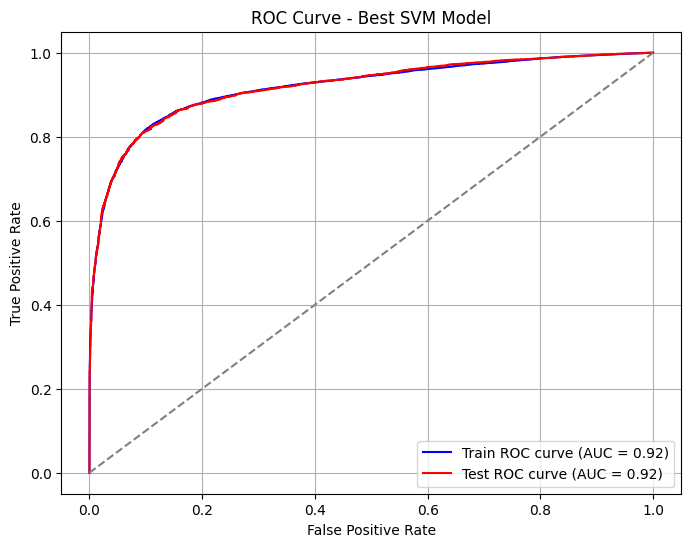

In [72]:
# Predict probabilities for SVM on train and test data
y_train_pred_best_svm = best_svm_model.predict_proba(X_train)[:, 1]
y_test_pred_best_svm = best_svm_model.predict_proba(X_test)[:, 1]

# ROC curve for SVM (train and test)
fpr_train_svm, tpr_train_svm, _ = roc_curve(y_train, y_train_pred_best_svm)
fpr_test_svm, tpr_test_svm, _ = roc_curve(y_test, y_test_pred_best_svm)

# Compute AUC for both train and test
train_auc_svm = auc(fpr_train_svm, tpr_train_svm)
test_auc_svm = auc(fpr_test_svm, tpr_test_svm)

# Plot ROC curves for SVM model
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train_svm,
    tpr_train_svm,
    color="blue",
    label="Train ROC curve (AUC = {:.2f})".format(train_auc_svm),
)
plt.plot(
    fpr_test_svm,
    tpr_test_svm,
    color="red",
    label="Test ROC curve (AUC = {:.2f})".format(test_auc_svm),
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best SVM Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### **3.2.3 - Model Evaluation (description to be modify)**

After training the SVM model, we evaluate its performance on the test data by calculating key metrics such as accuracy, confusion matrix, and classification report. These metrics provide valuable insights into the model's effectiveness in classifying **LOS** and **NLOS** instances.

The model achieved an accuracy of **85.02%**. It showed stronger performance in identifying **NLOS** instances, with precision and recall for **NLOS** being 1.0. In contrast, the model struggled more with correctly identifying **LOS**, as indicated by its 0.0 precision for this class. The confusion matrix further reveals that the model has a relatively low number of false positives and false negatives, suggesting generally solid classification performance. However, the disparity in precision and recall indicates that there is room for improvement, especially in correctly classifying **LOS** instances.

In [73]:
# --- SVM Model Evaluation ---
# Predict using the best SVM model
y_pred_best_svm = best_svm_model.predict(X_test)  # Prediction for test set

# Calculate accuracy of the SVM model
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)

# Generate the confusion matrix for the SVM model
conf_matrix_best_svm = confusion_matrix(y_test, y_pred_best_svm)  # Confusion Matrix

# Extract true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN)
TP_best_svm, TN_best_svm, FP_best_svm, FN_best_svm = (
    conf_matrix_best_svm[1, 1],
    conf_matrix_best_svm[0, 0],
    conf_matrix_best_svm[0, 1],
    conf_matrix_best_svm[1, 0],
)

# Print out the evaluation metrics for the SVM model
print(f"Best SVM Accuracy: {accuracy_best_svm:.4f}")
print(f"Best SVM Confusion Matrix:\n{conf_matrix_best_svm}")
print(
    f"Best SVM Classification Report:\n{classification_report(y_test, y_pred_best_svm)}"
)

Best SVM Accuracy: 0.8562
Best SVM Confusion Matrix:
[[3895  357]
 [ 851 3297]]
Best SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87      4252
         1.0       0.90      0.79      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



###### **3.1.3 - visualization graph** 

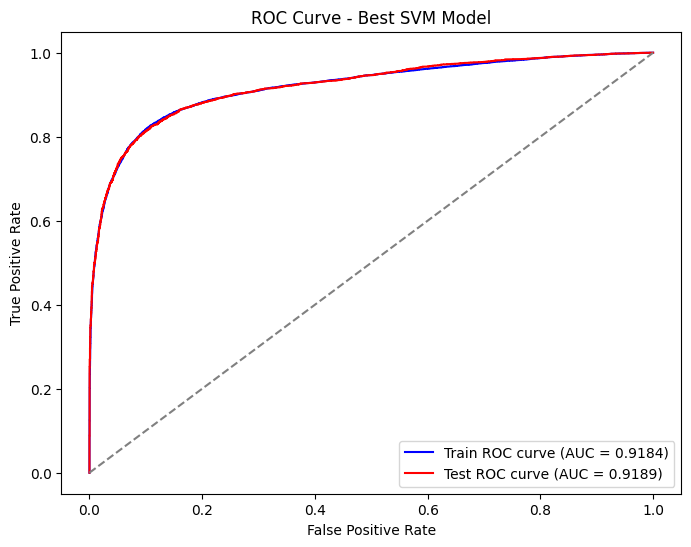

In [74]:
# ROC curve for train and test sets
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train,
    tpr_train,
    color="blue",
    label=f"Train ROC curve (AUC = {train_auc_svm:.4f})",
)
plt.plot(
    fpr_test, tpr_test, color="red", label=f"Test ROC curve (AUC = {test_auc_svm:.4f})"
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best SVM Model")
plt.legend(loc="lower right")
plt.show()

After performing hyperparameter tuning, the model was evaluated to assess its performance. The evaluation focused on key metrics such as accuracy, precision, recall, and ROC-AUC on the test dataset, to determine the model’s ability to generalize to unseen data.

##### **3.2.4 - Evaluation and Performance of the Best SVM Model (description to be modify)**

In [75]:
# Best SVM - Accuracy, Confusion Matrix, and Classification Report
print("\n### SVM Evaluation ###")
print(f"Best SVM Accuracy: {accuracy_best_svm:.4f}")
print(f"Best SVM Confusion Matrix:\n{conf_matrix_best_svm}")
print(
    f"Best SVM Classification Report:\n{classification_report(y_test, y_pred_best_svm)}"
)

# Print AUC for both models
train_auc_svm = roc_auc_score(y_train, y_train_pred_best_svm)
test_auc_svm = roc_auc_score(y_test, y_test_pred_best_svm)
print(
    f"Best SVM - Train ROC-AUC: {train_auc_svm:.4f}, Test ROC-AUC: {test_auc_svm:.4f}"
)


### SVM Evaluation ###
Best SVM Accuracy: 0.8562
Best SVM Confusion Matrix:
[[3895  357]
 [ 851 3297]]
Best SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87      4252
         1.0       0.90      0.79      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400

Best SVM - Train ROC-AUC: 0.9184, Test ROC-AUC: 0.9189


###### **3.1.3 - visualization graph** 

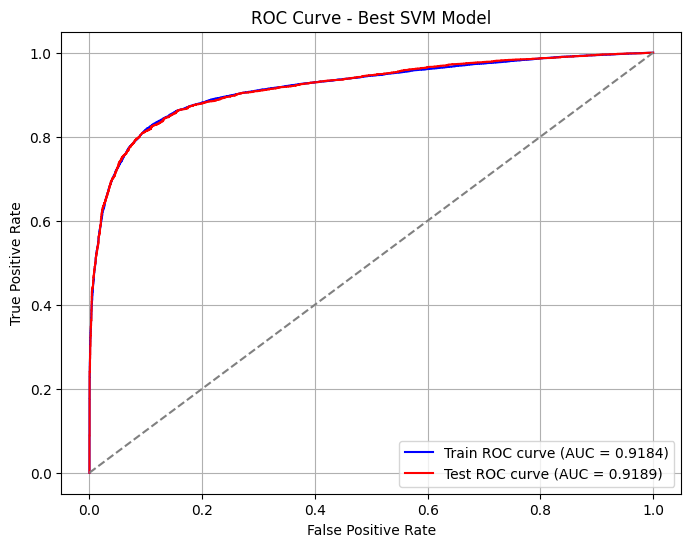

In [76]:
# Predict probabilities for train and test sets
y_train_pred_best_svm = best_svm_model.predict_proba(X_train)[
    :, 1
]  # Predict probabilities for class 1
y_test_pred_best_svm = best_svm_model.predict_proba(X_test)[
    :, 1
]  # Predict probabilities for class 1

# Compute ROC curve for train and test sets
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_best_svm)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_best_svm)

# Compute AUC for train and test
train_roc_auc = auc(fpr_train, tpr_train)
test_roc_auc = auc(fpr_test, tpr_test)

# Plot ROC curves for train and test sets
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train,
    tpr_train,
    color="blue",
    label=f"Train ROC curve (AUC = {train_roc_auc:.4f})",
)
plt.plot(
    fpr_test, tpr_test, color="red", label=f"Test ROC curve (AUC = {test_roc_auc:.4f})"
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.title("ROC Curve - Best SVM Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### **3.2.5 - Confusion Matrix Visualization (description to be added)**

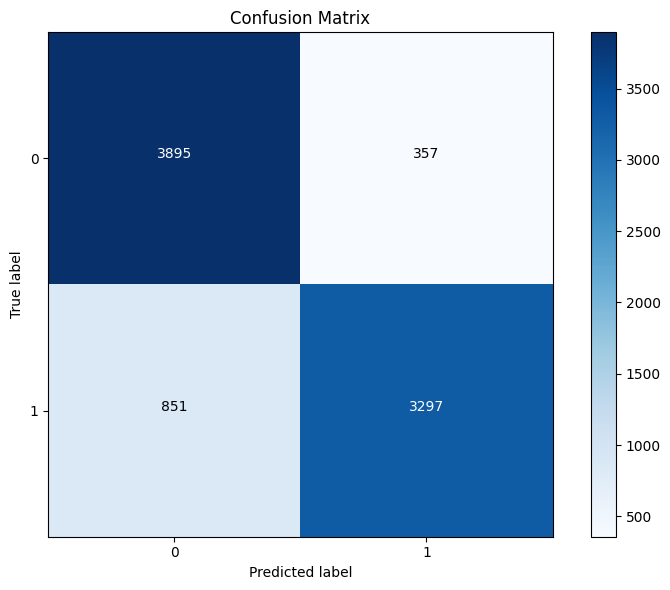

In [77]:
# Confusion matrix plot
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_best_svm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

thresh = conf_matrix_best_svm.max() / 2.  # Threshold to make text color readable
for i, j in itertools.product(range(conf_matrix_best_svm.shape[0]), range(conf_matrix_best_svm.shape[1])):
    plt.text(j, i, format(conf_matrix_best_svm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix_best_svm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


##### **3.2.6 - Conclusion: Performance of the Best SVM Model (Description to be added)**

============= FOLLOW THIS FORMAT!! =============
    
In conclusion, the **best Logistic SVM model** achieved an accuracy of 85.63%, demonstrating solid performance in classifying both NLOS and LOS instances.

The confusion matrix shows the model is effective at identifying NLOS (3871 True Negatives) but has a higher False Negative rate for LOS (826). The classification report indicates high precision for LOS (0.90) and strong recall for NLOS (0.91), with an F1-score of 0.87 for NLOS and 0.85 for LOS. 

The ROC-AUC scores (Train: 0.9185, Test: 0.9187) confirm the model's robust ability to distinguish between the two classes. Overall, the model is reliable, with a slight imbalance favoring the correct identification of NLOS instances.

#### **3.3 - Random Forest**

##### **3.3.1 - Hyperparameter Tuning (Description to be added)** 

XXXX

In [78]:
# --- Hyperparameter Tuning with GridSearchCV (if applicable) ---
param_grid_rf = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [None, 10, 20, 30],  # Maximum depth of the tree
    "min_samples_split": [
        2,
        5,
        10,
    ],  # Minimum number of samples required to split a node
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,
    verbose=1,  # Display progress
    scoring="roc_auc",  # Optimize for ROC-AUC
)

# Fit the grid search
grid_search_rf.fit(X_train, y_train)
best_rf_model = grid_search_rf.best_estimator_


# Print best hyperparameters
print(f"Best Random Forest hyperparameters: {grid_search_rf.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Random Forest hyperparameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}


##### **3.3.2 - Model Training and Testing (Description to be modify)** 

XXX

In [79]:
# Predict probabilities for SVM on train and test data
y_train_pred_best_svm = best_svm_model.predict_proba(X_train)[:, 1]
y_test_pred_best_svm = best_svm_model.predict_proba(X_test)[:, 1]

# Compute ROC-AUC for train and test
train_auc_svm = roc_auc_score(y_train, y_train_pred_best_svm)
test_auc_svm = roc_auc_score(y_test, y_test_pred_best_svm)

# Print ROC-AUC scores
print(f"SVM - Train ROC-AUC: {train_auc_svm:.4f}, Test ROC-AUC: {test_auc_svm:.4f}")

# ROC curve for SVM (train and test)
fpr_train_svm, tpr_train_svm, _ = roc_curve(y_train, y_train_pred_best_svm)
fpr_test_svm, tpr_test_svm, _ = roc_curve(y_test, y_test_pred_best_svm)

SVM - Train ROC-AUC: 0.9184, Test ROC-AUC: 0.9189


###### **3..3 - visualization graph** 

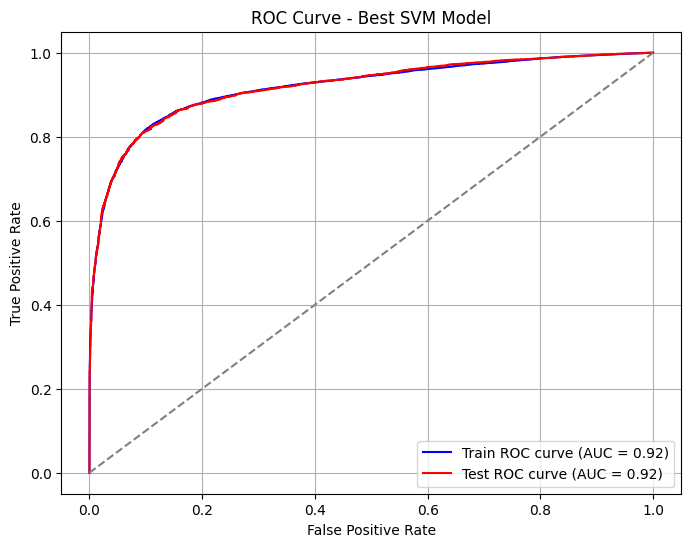

In [80]:
# Plot ROC curves for SVM model
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train_svm,
    tpr_train_svm,
    color="blue",
    label="Train ROC curve (AUC = {:.2f})".format(train_auc_svm),
)
plt.plot(
    fpr_test_svm,
    tpr_test_svm,
    color="red",
    label="Test ROC curve (AUC = {:.2f})".format(test_auc_svm),
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best SVM Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##### **3.3.3 - Model Evaluation**

In [81]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # Train

RandomForestClassifier(n_jobs=-1, random_state=42)

In [82]:
# --- Model Evaluation ---
y_pred_rf = rf_model.predict(X_test)  # Prediction on test set

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Generate confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# First 10 Actual vs Predicted values
comparison_rf = pd.DataFrame(
    {"Actual": y_test[:10].values, "Predicted": y_pred_rf[:10]}
)

# Print evaluation results
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Confusion Matrix:\n{conf_matrix_rf}")
print(
    f"Random Forest Classification Report:\n{classification_report(y_test, y_pred_rf)}"
)
print("\nFirst 10 Predicted vs. Actual Values (Random Forest):\n", comparison_rf)

Random Forest Accuracy: 0.9110
Random Forest Confusion Matrix:
[[3978  274]
 [ 474 3674]]
Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91      4252
         1.0       0.93      0.89      0.91      4148

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400


First 10 Predicted vs. Actual Values (Random Forest):
    Actual  Predicted
0     1.0        1.0
1     1.0        0.0
2     1.0        1.0
3     1.0        1.0
4     1.0        1.0
5     1.0        1.0
6     0.0        0.0
7     1.0        1.0
8     0.0        0.0
9     0.0        0.0


###### **3.1.3 - visualization graph** 

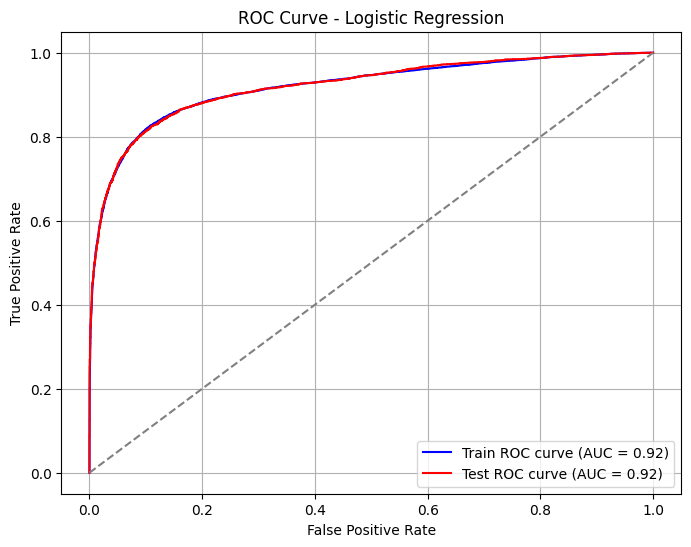

In [83]:
fpr_train_lr, tpr_train_lr, _ = roc_curve(y_train, y_train_pred_lr)
fpr_test_lr, tpr_test_lr, _ = roc_curve(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train_lr,
    tpr_train_lr,
    color="blue",
    label="Train ROC curve (AUC = {:.2f})".format(train_auc_lr),
)
plt.plot(
    fpr_test_lr,
    tpr_test_lr,
    color="red",
    label="Test ROC curve (AUC = {:.2f})".format(test_auc_lr),
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)

##### **3.3.4 - Evaluation and Performance of the Best Rnadom Forest Model (need to add???)**

In [84]:
# --- Model Evaluation ---
y_pred_rf = rf_model.predict(X_test)  # Prediction on test set

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Generate confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# First 10 Actual vs Predicted values
comparison_rf = pd.DataFrame(
    {"Actual": y_test[:10].values, "Predicted": y_pred_rf[:10]}
)

# Print evaluation results
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Confusion Matrix:\n{conf_matrix_rf}")
print(
    f"Random Forest Classification Report:\n{classification_report(y_test, y_pred_rf)}"
)
print("\nFirst 10 Predicted vs. Actual Values (Random Forest):\n", comparison_rf)

Random Forest Accuracy: 0.9110
Random Forest Confusion Matrix:
[[3978  274]
 [ 474 3674]]
Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91      4252
         1.0       0.93      0.89      0.91      4148

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400


First 10 Predicted vs. Actual Values (Random Forest):
    Actual  Predicted
0     1.0        1.0
1     1.0        0.0
2     1.0        1.0
3     1.0        1.0
4     1.0        1.0
5     1.0        1.0
6     0.0        0.0
7     1.0        1.0
8     0.0        0.0
9     0.0        0.0


###### **3.1.3 - visualization graph** 

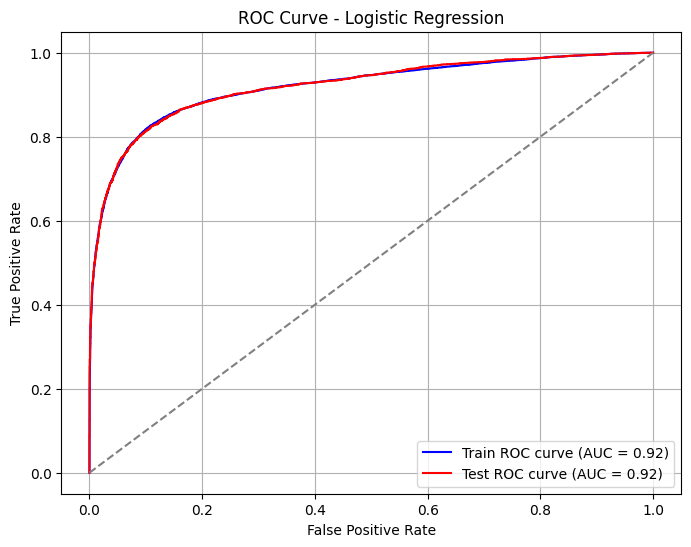

In [85]:
fpr_train_lr, tpr_train_lr, _ = roc_curve(y_train, y_train_pred_lr)
fpr_test_lr, tpr_test_lr, _ = roc_curve(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_train_lr,
    tpr_train_lr,
    color="blue",
    label="Train ROC curve (AUC = {:.2f})".format(train_auc_lr),
)
plt.plot(
    fpr_test_lr,
    tpr_test_lr,
    color="red",
    label="Test ROC curve (AUC = {:.2f})".format(test_auc_lr),
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)

##### **3.3.5 - Confusion Matrix Visualization (description to be added)**

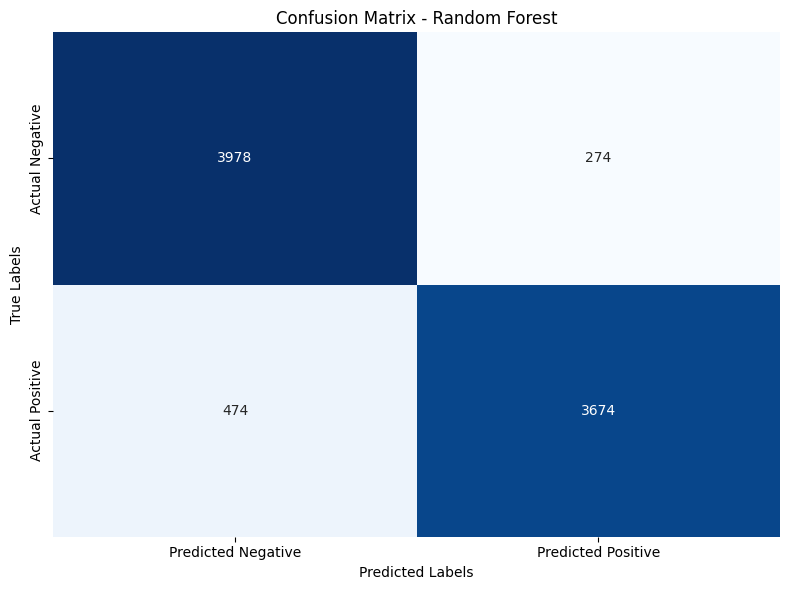

In [86]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"],
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

##### **3.3.5 - Conclusion: Performance of the Best Random Forest Model (descrioption to be added)**

XXX 

## **4 - Model Comparison and Analysis**

After training and tuning the models for Random Forest, SVM, and Logistic Regression, we evaluate their performance using key metrics and visualizations. These evaluations allow us to compare the models and identify the most suitable one for the task.

##### **4.1 - Models Evaluation**


After obtaining the best models for Random Forest, SVM, and Logistic Regression, we assess their performance on the test set using several key metrics and visualizations:

- **Accuracy**: Measures the proportion of correctly predicted instances.
- **AUC (Area Under the Curve)**: Provides a performance evaluation of the model, particularly useful for understanding the trade-off between True Positive Rate and False Positive Rate.
- **Confusion Matrix**: Shows a detailed breakdown of the classification results, including True Positives, False Positives, True Negatives, and False Negatives.
- **Precision-Recall Curve**: Visualizes the trade-off between Precision and Recall, especially important for imbalanced datasets.

By comparing these metrics and visualizations, we can determine the best-performing model and select the most appropriate one for the given problem. The selected model is then saved for future use.

In [87]:
# random forest
rf_accuracy = accuracy_score(y_test, best_rf_model.predict(X_test))
rf_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Evaluate SVM
svm_accuracy = accuracy_score(y_test, best_svm_model.predict(X_test))
svm_auc = roc_auc_score(y_test, best_svm_model.predict_proba(X_test)[:, 1])

# Evaluate Logistic Regression
lr_accuracy = accuracy_score(y_test, best_lr_model.predict(X_test))
lr_auc = roc_auc_score(y_test, best_lr_model.predict_proba(X_test)[:, 1])

print(f"Random Forest AUC: {rf_auc:.4f}, Accuracy: {rf_accuracy:.4f}")
print(f"SVM AUC: {svm_auc:.4f}, Accuracy: {svm_accuracy:.4f}")
print(f"Logistic Regression AUC: {lr_auc:.4f}, Accuracy: {lr_accuracy:.4f}")

Random Forest AUC: 0.9687, Accuracy: 0.9108
SVM AUC: 0.9189, Accuracy: 0.8562
Logistic Regression AUC: 0.8973, Accuracy: 0.8329


/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


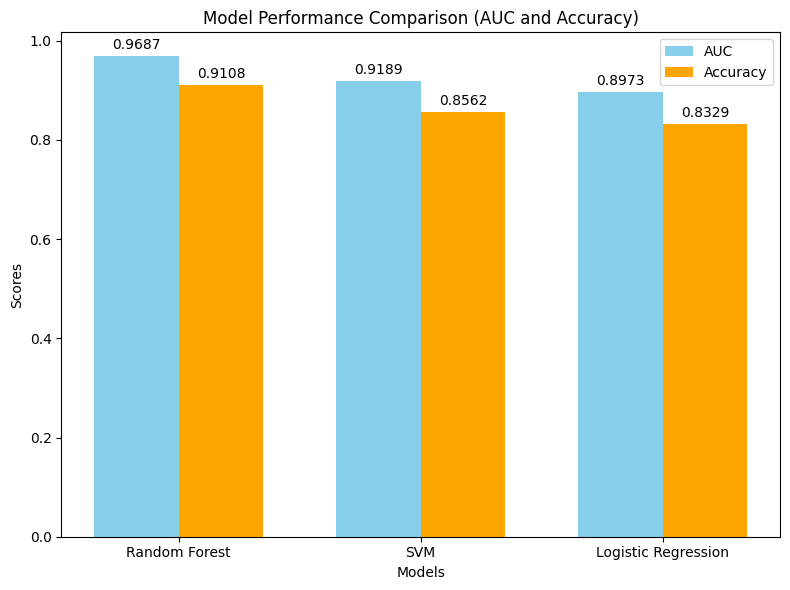

In [88]:
# Metrics for plotting
models = ["Random Forest", "SVM", "Logistic Regression"]
auc_scores = [rf_auc, svm_auc, lr_auc]
accuracy_scores = [rf_accuracy, svm_accuracy, lr_accuracy]

# Plotting AUC and Accuracy
x = np.arange(len(models))  # The label locations
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(x - width / 2, auc_scores, width, label="AUC", color="skyblue")
bars2 = ax.bar(x + width / 2, accuracy_scores, width, label="Accuracy", color="orange")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Models")
ax.set_ylabel("Scores")
ax.set_title("Model Performance Comparison (AUC and Accuracy)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()


# Attach the text labels above the bars
def add_text(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.annotate(
            f"{value:.4f}",  # Display the value with 4 decimal places
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )


add_text(bars1, auc_scores)
add_text(bars2, accuracy_scores)

plt.tight_layout()
plt.show()

**Model Comparison and Selection of the Best Model**

After training and evaluating the models for Random Forest, SVM, and Logistic Regression, we compare their performance based on several key metrics. These metrics include Accuracy, AUC, Confusion Matrix, and Precision-Recall Curve. By analyzing these evaluations, we can determine which model best meets the requirements of the task at hand.

The model that performs the best across these evaluations is selected as the final model. This model is then saved for future use, ensuring that it can be deployed or further fine-tuned as needed.

In [89]:
if rf_auc > svm_auc and rf_auc > lr_auc:
    best_model = best_rf_model
    print("Best Model: Random Forest")
elif svm_auc > rf_auc and svm_auc > lr_auc:
    best_model = best_svm_model
    print("Best Model: SVM")
else:
    best_model = best_lr_model
    print("Best Model: Logistic Regression")

Best Model: Random Forest


##### **4.2 - ROC Curve Analysis of Model Performance**

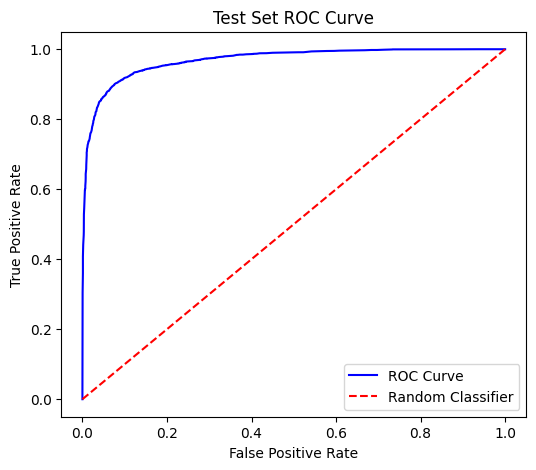

In [90]:
# ROC Curve for the best model
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])

# Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(
    fpr, tpr, color="b", label="ROC Curve"
)  # Plot the ROC curve for the best model
plt.plot(
    [0, 1], [0, 1], color="r", linestyle="--", label="Random Classifier"
)  # Random classifier (diagonal)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test Set ROC Curve")
plt.legend(loc="lower right")
plt.show()

## **5 - Model Deployment**
After selecting and evaluating the best model, we save the trained model for future use and easy deployment. This allows us to utilize the model without needing to retrain it each time. The saved model can be loaded into production environments for making predictions on new, unseen data.

In [91]:
# import libraries

try:
    import os
    import joblib
    from sklearn.metrics import roc_auc_score

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


### **5.1 - Create Directories for Storing Models**

In [92]:
# Create the main directory for final models if it doesn't exist
folder_name = "final_models"
os.makedirs(folder_name, exist_ok=True)

# Create a subdirectory specifically for algorithm models
algo_folder = os.path.join(folder_name, "algo_models")
os.makedirs(algo_folder, exist_ok=True)

### **5.2 - Save the Best Overall Model**

In [93]:
# Save the overall best model (across all algorithms)
overallBest_filename = os.path.join(folder_name, "best_overall_model.pkl")
joblib.dump(best_model, overallBest_filename)
print(f"Final model saved as {overallBest_filename}")

Final model saved as final_models/best_overall_model.pkl


### **5.3 - Save the Best Models for Each Algorithm**

#### **5.3.1 - Logistic Regression Model**

In [94]:
# Save the best Logistic Regression model
LR_filename = os.path.join(algo_folder, "logistic_regression_model.pkl")
joblib.dump(best_lr_model, LR_filename)
print(f"Logistic Regression model saved as {LR_filename}")

Logistic Regression model saved as final_models/algo_models/logistic_regression_model.pkl


#### **5.3.2 - SVM Model**

In [95]:
# Save the best SVM model
SVM_filename = os.path.join(algo_folder, "SVM_model.pkl")
joblib.dump(best_svm_model, SVM_filename)
print(f"SVM model saved as {SVM_filename}")

SVM model saved as final_models/algo_models/SVM_model.pkl


#### **5.3.3 - Random Forest Model**

In [96]:
# Save the best Random Forest model
RF_filename = os.path.join(algo_folder, "RF_model.pkl")
joblib.dump(best_rf_model, RF_filename)
print(f"Random Forest model saved as {RF_filename}")

Random Forest model saved as final_models/algo_models/RF_model.pkl
